### MSE 404 DFT Project Aluminum from First Principles

**Name: Zihan (Joe) Yang, Email: joeyang2@illinois.edu**

#### A1. What the assistant gets wrong [30 points]

Model: Gemini 3.5 Flash-lite (No memory from my previous work)

Prompt: Write a Quantum ESPRESSO input file for an scf calculation of fcc aluminum for me. Paths on my computers are prefix = 'aluminum', outdir = '/Users/zhy/Aluminum-from-First-Principles/qe-out/',

The generated script is pasted here,

&control

   calculation = 'scf'

   restart_mode = 'from_scratch'

   prefix       = 'aluminum'

   outdir       = '/Users/zhy/Aluminum-from-First-Principles/qe-out/'

   pseudo_dir   = './'

   tprnfor      = .true.

   tstress      = .true.

/

&system

   ibrav       = 2

   celldm(1)   = 7.6532        ! Lattice parameter in Bohr (~4.05 Angstroms)

   nat         = 1

   ntyp        = 1

   ecutwfc     = 30.0          ! Wavefunction kinetic energy cutoff (Ry)

   ecutrho     = 120.0         ! Charge density kinetic energy cutoff (Ry)

   occupations = 'smearing'

   smearing    = 'methfessel-paxton'

   degauss     = 0.02          ! Smearing width (Ry)

/

&electrons

   conv_thr    = 1.0d-8        $ Convergence threshold for self-consistency

   mixing_beta = 0.7           ! Mixing factor for potential continuation

/

ATOMIC_SPECIES

 Al  26.9815  Al.pbe-n-kjpaw_psl.1.0.upf

ATOMIC_POSITIONS crystal

 Al  0.000000000  0.000000000  0.000000000

K_POINTS automatic

 12 12 12  1 1 1

No result appears, a CRASH message occurs, which reports "could not find namelist &control".


The important note from AI:

Pseudopotential: Make sure you download an aluminum pseudopotential (e.g., Al.pbe-n-kjpaw_psl.1.0.upf or similar from the SSSP library or Quantum ESPRESSO website) and place it in your pseudo_dir path (set to ./ in the script, meaning the current working directory).

Lattice Constant: celldm(1) = 7.6532 Bohr corresponds roughly to the experimental lattice constant of aluminum ($\approx 4.05$ Å). You can optimize this value later using a variable-cell relaxation (vc-relax).

Model: ChatGPT 5.6 Sol (Some memory and frequently used by the user)

Same prompt as before.

The generated script is pasted here,

&CONTROL
    calculation = 'scf',
    
    prefix = 'aluminum',

    outdir = '/Users/zhy/Aluminum-from-First-Principles/qe-out/',

    pseudo_dir = './pseudo/',

/

&SYSTEM

    ibrav = 2,

    celldm(1) = 7.6534,

    nat = 1,

    ntyp = 1,

    ecutwfc = 40.0,

    ecutrho = 320.0,

    occupations = 'smearing',

    smearing = 'mv',

    degauss = 0.02,

/

&ELECTRONS

    conv_thr = 1.0d-8,

    mixing_beta = 0.7,
/

ATOMIC_SPECIES

Al  26.9815385  Al.pbe-n-kjpaw_psl.1.0.0.UPF

ATOMIC_POSITIONS crystal

Al  0.0  0.0  0.0

K_POINTS automatic

12 12 12  0 0 0

No result occurs, a CRASH with "opening input file" is reported.

A few important points generated with AI:

ibrav = 2 is the fcc primitive lattice in Quantum ESPRESSO.

celldm(1) = 7.6534 bohr corresponds to approximately 4.05 Å, a reasonable experimental lattice constant for Al.

Because Al is a metal, use smearing rather than occupations='fixed'.

12 × 12 × 12 is a reasonable starting k-point mesh, but you should perform a k-point convergence test.

ecutwfc = 40 Ry is only a starting value. Your required cutoff depends on the pseudopotential.

ecutrho = 320 Ry = 8 × ecutwfc is reasonable for a PAW pseudopotential.

Change

Al.pbe-n-kjpaw_psl.1.0.0.UPF

to the exact Al pseudopotential filename you actually have.

Likewise, change pseudo_dir if your pseudopotential is stored elsewhere.

#### A2. Joint convergence: the three-parameter problem [40 points]

In [ ]:
#!/usr/bin/env python3
#run via terminal as:
#python3 al_convergence.py grid --dry-run
#python3 al_convergence.py grid --run --nproc 2
"""Generate and optionally run fixed-cell Al convergence studies with QE.

The script deliberately does not launch Quantum ESPRESSO unless ``--run`` is
provided. That makes it safe to inspect the generated inputs before spending
time on the 36-point cutoff/k-mesh grid or the subsequent smearing scans.
"""

from __future__ import annotations

import argparse
import csv
import math
import re
import subprocess
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable


PROJECT_ROOT = Path(__file__).resolve().parents[1]
DEFAULT_PW = PROJECT_ROOT / ".qe" / "bin" / "pw.x"
DEFAULT_MPI = Path("/opt/homebrew/bin/mpirun")
DEFAULT_PSEUDO = PROJECT_ROOT / "Al.pbe-n-van.UPF"
DEFAULT_RUNS_DIR = PROJECT_ROOT / "convergence-runs"

# Required fixed-cell study settings.
ALAT_BOHR = 9.0
ECUT_VALUES_RY = (15.0, 20.0, 25.0, 30.0, 35.0, 40.0)
KMESH_VALUES = (4, 6, 8, 10, 12, 16)
BASE_DEGAUSS_RY = 0.05
SMEARING_VALUES_RY = (0.05, 0.02, 0.01)
ECUTRHO_RATIO = 8.0

FINAL_ENERGY_RE = re.compile(
    r"^\s*!\s+total\s+energy\s*=\s*"
    r"([-+]?(?:\d+\.\d*|\d*\.\d+|\d+)(?:[EeDd][-+]?\d+)?)\s+Ry",
    re.MULTILINE,
)


@dataclass(frozen=True)
class RunSpec:
    """One independent SCF calculation in a convergence study."""

    study: str
    ecutwfc_ry: float
    kmesh: int
    degauss_ry: float
    ecutrho_ratio: float

    @property
    def ecutrho_ry(self) -> float:
        return self.ecutwfc_ry * self.ecutrho_ratio

    @property
    def tag(self) -> str:
        return (
            f"ecut-{self.ecutwfc_ry:05.1f}-ry_"
            f"k-{self.kmesh:02d}x{self.kmesh:02d}x{self.kmesh:02d}_"
            f"degauss-{self.degauss_ry:.3f}-ry"
        )

    @property
    def prefix(self) -> str:
        return f"aluminum_{self.tag.replace('.', 'p')}"


def make_input(spec: RunSpec, pseudo: Path, scratch_dir: Path) -> str:
    """Render a self-contained QE input for a single fixed-cell SCF point."""

    pseudo_dir = pseudo.parent.resolve().as_posix()
    outdir = scratch_dir.resolve().as_posix()
    return f"""&CONTROL
  calculation = 'scf',
  restart_mode = 'from_scratch',
  prefix = '{spec.prefix}',
  tstress = .true.,
  tprnfor = .true.,
  pseudo_dir = '{pseudo_dir}/',
  outdir = '{outdir}/'
/
&SYSTEM
  ibrav = 2,
  celldm(1) = {ALAT_BOHR:.1f},
  nat = 1,
  ntyp = 1,
  ecutwfc = {spec.ecutwfc_ry:.6f},
  ecutrho = {spec.ecutrho_ry:.6f},
  occupations = 'smearing',
  smearing = 'methfessel-paxton',
  degauss = {spec.degauss_ry:.6f}
/
&ELECTRONS
  diagonalization = 'david',
  mixing_mode = 'plain',
  conv_thr = 1.0d-8
/
ATOMIC_SPECIES
  Al  26.982  {pseudo.name}
ATOMIC_POSITIONS alat
  Al  0.00  0.00  0.00
K_POINTS automatic
  {spec.kmesh} {spec.kmesh} {spec.kmesh}  0 0 0
"""


def parse_final_energy_text(contents: str) -> float:
    """Return the last QE total energy printed in ``contents``, in Ry."""

    matches = list(FINAL_ENERGY_RE.finditer(contents))
    if not matches:
        raise ValueError("No final '! total energy' line found")
    return float(matches[-1].group(1).replace("D", "E").replace("d", "e"))


def read_qe_output(output: Path) -> str:
    return output.read_text(encoding="utf-8", errors="replace")


def is_converged_scf_output(contents: str) -> bool:
    """Accept only a normally completed, self-consistent QE calculation."""

    return (
        "JOB DONE." in contents
        and "convergence has been achieved" in contents
        and "convergence NOT achieved" not in contents
    )


def study_specs(args: argparse.Namespace) -> list[RunSpec]:
    if args.study == "grid":
        return [
            RunSpec(
                study="cutoff-kmesh",
                ecutwfc_ry=ecut,
                kmesh=kmesh,
                degauss_ry=BASE_DEGAUSS_RY,
                ecutrho_ratio=args.ecutrho_ratio,
            )
            for ecut in ECUT_VALUES_RY
            for kmesh in KMESH_VALUES
        ]

    if args.best_ecut is None:
        raise ValueError("The smearing study requires --best-ecut after reviewing the grid.")
    return [
        RunSpec(
            study="smearing",
            ecutwfc_ry=args.best_ecut,
            kmesh=kmesh,
            degauss_ry=degauss,
            ecutrho_ratio=args.ecutrho_ratio,
        )
        for degauss in SMEARING_VALUES_RY
        for kmesh in KMESH_VALUES
    ]


def paths_for(runs_dir: Path, spec: RunSpec) -> tuple[Path, Path, Path, Path]:
    run_dir = runs_dir / spec.study / spec.tag
    return (
        run_dir,
        run_dir / "Al.scf.inp",
        run_dir / "Al.scf.out",
        run_dir / "qe-out",
    )


def run_qe(
    *,
    spec: RunSpec,
    input_path: Path,
    output_path: Path,
    mpi: Path,
    pw: Path,
    nproc: int,
) -> tuple[str, float | None, str]:
    """Execute one point and return its state, energy, and explanatory note."""

    command = [str(mpi), "-np", str(nproc), str(pw), "-in", input_path.name]
    with output_path.open("w", encoding="utf-8") as stream:
        completed = subprocess.run(
            command,
            cwd=input_path.parent,
            stdout=stream,
            stderr=subprocess.STDOUT,
            check=False,
        )

    contents = read_qe_output(output_path)
    try:
        energy = parse_final_energy_text(contents)
    except ValueError as error:
        return "failed", None, f"exit={completed.returncode}; {error}"

    if completed.returncode != 0:
        return "failed", None, f"exit={completed.returncode}"
    if not is_converged_scf_output(contents):
        return "failed", None, "QE did not report a normally converged SCF."
    return "success", energy, ""


def completed_result(output_path: Path) -> float | None:
    """Return an existing successful result, if the output is usable."""

    if not output_path.is_file():
        return None
    contents = read_qe_output(output_path)
    if not is_converged_scf_output(contents):
        return None
    try:
        return parse_final_energy_text(contents)
    except ValueError:
        return None


def manifest_row(
    spec: RunSpec,
    state: str,
    energy: float | None,
    note: str,
    input_path: Path,
    output_path: Path,
) -> dict[str, str | float | int]:
    return {
        "study": spec.study,
        "ecutwfc_ry": spec.ecutwfc_ry,
        "ecutrho_ry": spec.ecutrho_ry,
        "ecutrho_ratio": spec.ecutrho_ratio,
        "kmesh": spec.kmesh,
        "degauss_ry": spec.degauss_ry,
        "status": state,
        "energy_ry": "" if energy is None else energy,
        "input_path": str(input_path),
        "output_path": str(output_path),
        "note": note,
    }


def write_manifest(path: Path, rows: Iterable[dict[str, str | float | int]]) -> None:
    fieldnames = (
        "study",
        "ecutwfc_ry",
        "ecutrho_ry",
        "ecutrho_ratio",
        "kmesh",
        "degauss_ry",
        "status",
        "energy_ry",
        "input_path",
        "output_path",
        "note",
    )
    with path.open("w", newline="", encoding="utf-8") as stream:
        writer = csv.DictWriter(stream, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def validate_run_environment(pw: Path, mpi: Path, pseudo: Path) -> None:
    missing: list[str] = []
    if not pw.is_file() or not (pw.stat().st_mode & 0o111):
        missing.append(f"QE executable: {pw}")
    if not mpi.is_file() or not (mpi.stat().st_mode & 0o111):
        missing.append(f"MPI launcher: {mpi}")
    if not pseudo.is_file():
        missing.append(f"Al pseudopotential: {pseudo}")
    if missing:
        raise FileNotFoundError("Missing required path(s):\n  " + "\n  ".join(missing))


def build_parser() -> argparse.ArgumentParser:
    parser = argparse.ArgumentParser(
        description=(
            "Generate or run fixed-alat aluminum QE convergence calculations. "
            "QE runs only when --run is explicitly supplied."
        )
    )
    parser.add_argument("study", choices=("grid", "smearing"))
    parser.add_argument(
        "--best-ecut",
        type=float,
        help="Wavefunction cutoff (Ry) selected from the grid; required for smearing.",
    )
    parser.add_argument(
        "--ecutrho-ratio",
        type=float,
        default=ECUTRHO_RATIO,
        help=f"Fixed ecutrho / ecutwfc ratio for all points (default: {ECUTRHO_RATIO:g}).",
    )
    parser.add_argument(
        "--runs-dir",
        type=Path,
        default=DEFAULT_RUNS_DIR,
        help=f"Directory for generated cases and results (default: {DEFAULT_RUNS_DIR}).",
    )
    parser.add_argument("--pseudo", type=Path, default=DEFAULT_PSEUDO)
    parser.add_argument("--pw", type=Path, default=DEFAULT_PW)
    parser.add_argument("--mpi", type=Path, default=DEFAULT_MPI)
    parser.add_argument("--nproc", type=int, default=2, help="Local MPI ranks (default: 2).")
    parser.add_argument("--run", action="store_true", help="Actually launch PWSCF for each point.")
    parser.add_argument("--force", action="store_true", help="Rerun points with completed output files.")
    parser.add_argument(
        "--dry-run",
        action="store_true",
        help="Print the plan only; do not create inputs, outputs, or directories.",
    )
    return parser


def main() -> int:
    args = build_parser().parse_args()
    if args.nproc < 1:
        raise ValueError("--nproc must be at least 1")
    if not math.isfinite(args.ecutrho_ratio) or args.ecutrho_ratio < 8.0:
        raise ValueError("Use an ecutrho ratio of at least 8 for this ultrasoft pseudopotential.")
    if args.study == "smearing" and (
        args.best_ecut is None
        or not math.isfinite(args.best_ecut)
        or args.best_ecut <= 0.0
    ):
        raise ValueError("--best-ecut must be a positive finite cutoff for the smearing study.")
    if args.dry_run and args.run:
        raise ValueError("Choose either --dry-run or --run, not both.")

    specs = study_specs(args)
    runs_dir = args.runs_dir.resolve()
    pseudo = args.pseudo.resolve()
    pw = args.pw.resolve()
    mpi = args.mpi.resolve()

    print(
        f"Planned {len(specs)} {args.study} calculations: alat={ALAT_BOHR:.1f} bohr, "
        f"ecutrho/ecutwfc={args.ecutrho_ratio:g}."
    )
    if args.dry_run:
        for spec in specs:
            _, input_path, output_path, _ = paths_for(runs_dir, spec)
            print(f"  {spec.tag}\n    input:  {input_path}\n    output: {output_path}")
        return 0

    if args.run:
        validate_run_environment(pw, mpi, pseudo)
    elif not pseudo.is_file():
        raise FileNotFoundError(f"Al pseudopotential not found: {pseudo}")

    rows: list[dict[str, str | float | int]] = []
    failed = False
    for spec in specs:
        run_dir, input_path, output_path, scratch_dir = paths_for(runs_dir, spec)
        run_dir.mkdir(parents=True, exist_ok=True)
        scratch_dir.mkdir(exist_ok=True)
        input_path.write_text(make_input(spec, pseudo, scratch_dir), encoding="utf-8")

        state = "generated"
        energy: float | None = None
        note = "QE not launched; rerun with --run after reviewing inputs."
        if args.run:
            cached_energy = None if args.force else completed_result(output_path)
            if cached_energy is not None:
                state, energy, note = "cached", cached_energy, "Existing completed output retained."
            else:
                state, energy, note = run_qe(
                    spec=spec,
                    input_path=input_path,
                    output_path=output_path,
                    mpi=mpi,
                    pw=pw,
                    nproc=args.nproc,
                )
            failed = failed or state == "failed"

        rows.append(manifest_row(spec, state, energy, note, input_path, output_path))
        print(f"{state:9s} {spec.tag}" + ("" if energy is None else f"  {energy:.10f} Ry"))

    study_dir = runs_dir / specs[0].study
    manifest = study_dir / "results.csv"
    write_manifest(manifest, rows)
    print(f"Wrote manifest: {manifest}")
    if not args.run:
        print("No QE calculations were launched. Add --run when you are ready.")
    return 1 if failed else 0


if __name__ == "__main__":
    try:
        raise SystemExit(main())
    except (FileNotFoundError, ValueError) as error:
        print(f"error: {error}", file=sys.stderr)
        raise SystemExit(2)


Choose ecutwfc = 35 Ry and ecutrho = 280 Ry as the conservative operational cutoff for the k-point/smearing study. The relative k-mesh behavior is already indistinguishable from 50 Ry within 0.045 meV/atom, while 40–50 Ry adds little for this quantity. 

k-mesh errors relative to $16^3$:

| Mesh | 0.05 Ry | 0.02 Ry | 0.01 Ry |
|---:|---:|---:|---:|
| 4³ | +151.623 | +181.139 | +177.424 |
| 6³ | −43.485 | −44.428 | −45.212 |
| 8³ | +14.426 | +20.061 | +19.684 |
| 10³ | −3.810 | −12.833 | −14.162 |
| 12³ | −0.317 | −1.714 | −0.664 |
| 16³ | 0 | 0 | 0 |

The curves oscillate, as expected for metallic Fermi-surface sampling. The 12³→16³ changes are 0.317, 1.714, and 0.664 meV/atom for degauss = 0.05, 0.02, and 0.01 Ry, respectively. Therefore, report 16×16×16 as the best-supported common mesh: 12³ still fails a 1 meV/atom comparison for 0.02 Ry, and the lower-smearing scans expose stronger mesh sensitivity.

End result:

ecutwfc = 35 Ry

ecutrho = 280 Ry

K_POINTS automatic

16 16 16 0 0 0

occupations = 'smearing'

smearing = 'mp'

degauss = 0.01 Ry

Note on discussion with AI for convergence: With results only through 40 Ry, AI initially treated the small 35→40 change and lower cost as evidence that 35 Ry was economical; that was only an adjacent-step heuristic, not a controlled convergence result. 

Critically, without 45–50 Ry references, AI could not bound the remaining error, and a strict raw-total-energy target of 1 meV/atom would instead favor 40 Ry. After testing 45 and 50 Ry, AI used the course-appropriate metric— $E(k)-E(16^3)$ once it is supervised, not absolute pseudopotential energy—and found the whole 35-Ry k-mesh curve was within 0.045 meV/atom of the 50-Ry curve. Thus, 35 Ry is defensible as the conservative working cutoff for this k-point/smearing study, while 40 Ry remains the safer choice for a stricter raw-energy or property-specific target.

**Present the two-dimensional Ecut × k-mesh scan as a single figure — a heat map or a contour plot of the energy error per atom relative to your best-converged calculation works well. Use a logarithmic color scale. Mark the parameter combination you select.**

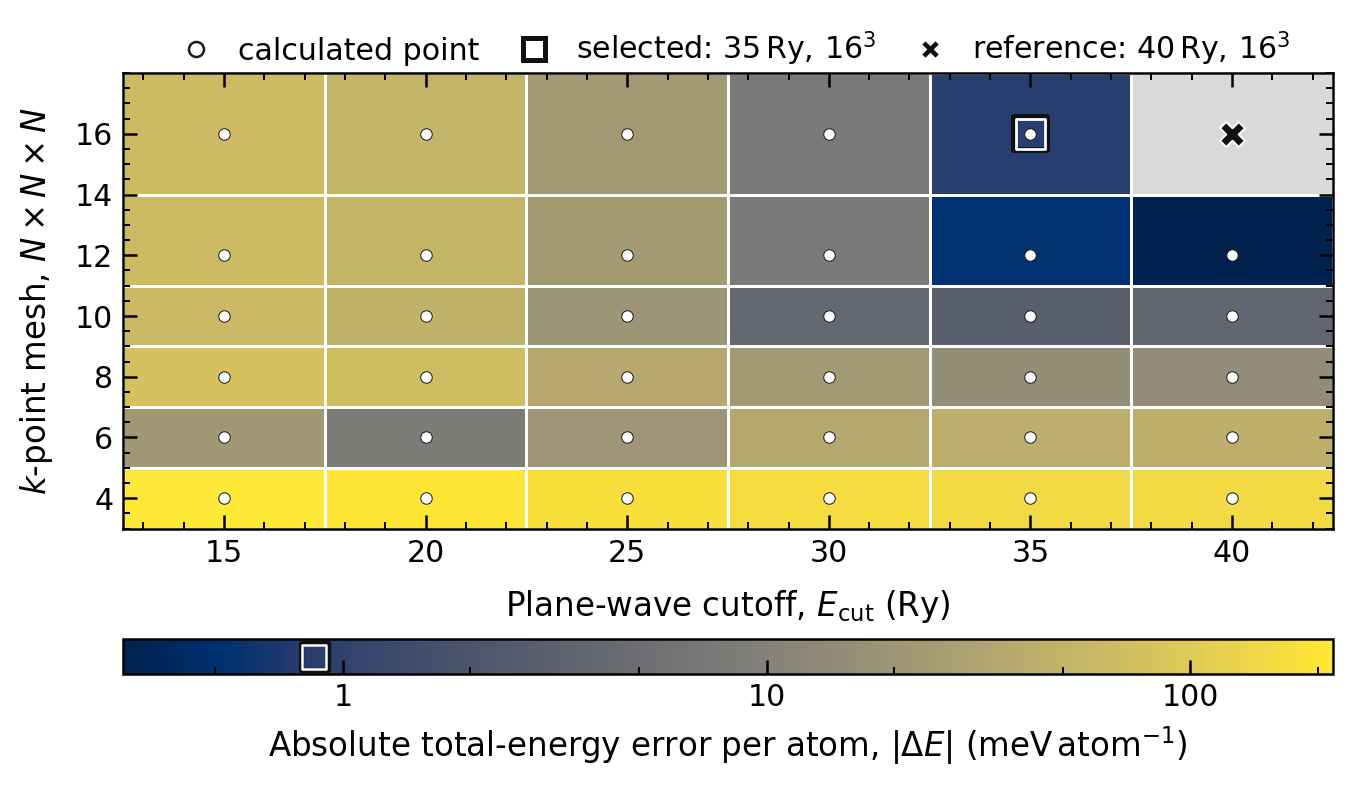

In [13]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from matplotlib.ticker import (
    FixedLocator,
    FormatStrFormatter,
    FuncFormatter,
    LogLocator,
    MultipleLocator,
    NullFormatter,
)

# ------------------------------------------------------------------
# Aluminum DFT project visual style — preserve in future figures.
# ------------------------------------------------------------------
mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",
    "axes.linewidth": 1.0,
    "figure.dpi": 180,
    "savefig.dpi": 900,
})

SCALAR_CMAP = "cividis"
REFERENCE_GRAY = "#D9D9D9"
POINT_FACE = "#FFFFFF"
POINT_EDGE = "#1A1A1A"
SELECT_OUTER = "#111111"
SELECT_INNER = "#FFFFFF"
CELL_BORDER = "#FFFFFF"

# ------------------------------------------------------------------
# Read the completed Ecut × k-mesh scan.
# ------------------------------------------------------------------
csv_path = Path("convergence-runs/cutoff-kmesh/results.csv")
if not csv_path.exists():
    csv_path = Path(
        "/Users/zhy/Aluminum-from-First-Principles/"
        "convergence-runs/cutoff-kmesh/results.csv"
    )

df = pd.read_csv(csv_path)
df = df.loc[
    (df["study"] == "cutoff-kmesh")
    & df["energy_ry"].notna()
    & (df["ecutwfc_ry"] <= 40.0)
].copy()

REF_ECUT, REF_KMESH = 40.0, 16
SELECTED_ECUT, SELECTED_KMESH = 35.0, 16

RY_TO_MEV = 13_605.693
N_ATOMS = 1

reference = df.loc[
    (df["ecutwfc_ry"] == REF_ECUT) &
    (df["kmesh"] == REF_KMESH),
    "energy_ry",
]
assert len(reference) == 1, "Reference calculation was not found."
E_ref_ry = reference.iloc[0]

energy_ry = (
    df.pivot(index="kmesh", columns="ecutwfc_ry", values="energy_ry")
      .sort_index()
      .sort_index(axis=1)
)
assert not energy_ry.isna().any().any(), "The Ecut × k-mesh grid is incomplete."

error_mev_atom = (
    (energy_ry - E_ref_ry).abs() * RY_TO_MEV / N_ATOMS
)

cutoffs = energy_ry.columns.to_numpy(dtype=float)
kmeshes = energy_ry.index.to_numpy(dtype=float)

def cell_edges(values):
    midpoint = (values[:-1] + values[1:]) / 2
    return np.r_[
        values[0] - (midpoint[0] - values[0]),
        midpoint,
        values[-1] + (values[-1] - midpoint[-1]),
    ]

ecut_edges = cell_edges(cutoffs)
kmesh_edges = cell_edges(kmeshes)

Z = error_mev_atom.to_numpy()
nonzero_Z = Z[Z > 0]
Z_log = np.ma.masked_equal(Z, 0.0)

cmap = plt.colormaps[SCALAR_CMAP].copy()
cmap.set_bad(REFERENCE_GRAY)

# ------------------------------------------------------------------
# Horizontal figure with symbol key in white space.
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))
fig.subplots_adjust(left=0.14, right=0.98, bottom=0.27, top=0.84)

image = ax.pcolormesh(
    ecut_edges,
    kmesh_edges,
    Z_log,
    shading="flat",
    cmap=cmap,
    norm=LogNorm(vmin=nonzero_Z.min(), vmax=nonzero_Z.max()),
    edgecolors=CELL_BORDER,
    linewidth=0.45,
)

# Show every calculated grid point.
X, Y = np.meshgrid(cutoffs, kmeshes)
ax.scatter(
    X.ravel(), Y.ravel(),
    s=21,
    marker="o",
    facecolors=POINT_FACE,
    edgecolors=POINT_EDGE,
    linewidths=0.40,
    zorder=3,
)

# Selected: 35 Ry, 16³.
ax.scatter(
    SELECTED_ECUT, SELECTED_KMESH,
    marker="s", s=170,
    facecolors="none",
    edgecolors=SELECT_OUTER,
    linewidths=2.4,
    zorder=4,
)
ax.scatter(
    SELECTED_ECUT, SELECTED_KMESH,
    marker="s", s=140,
    facecolors="none",
    edgecolors=SELECT_INNER,
    linewidths=1.1,
    zorder=5,
)

# Reference: 40 Ry, 16³; zero error is shown in gray.
ax.scatter(
    REF_ECUT, REF_KMESH,
    marker="X", s=100,
    facecolors=SELECT_OUTER,
    edgecolors=SELECT_INNER,
    linewidths=0.8,
    zorder=6,
)

# Four x-axis subticks per 5-Ry interval.
ax.xaxis.set_major_locator(FixedLocator(cutoffs))
ax.xaxis.set_major_formatter(FormatStrFormatter("%.0f"))
ax.xaxis.set_minor_locator(MultipleLocator(1))

# Three y-axis subticks per 2-unit interval.
ax.yaxis.set_major_locator(FixedLocator(np.arange(4, 17, 2)))
ax.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))
ax.yaxis.set_minor_locator(MultipleLocator(0.5))

# Ticks point inward.
ax.tick_params(
    axis="both", which="major",
    direction="in", top=True, right=True,
    length=5.5, width=1.0,
    labelsize=12, pad=4,
)
ax.tick_params(
    axis="both", which="minor",
    direction="in", top=True, right=True,
    length=2.7, width=0.8,
)

ax.set_xlabel(
    r"Plane-wave cutoff, $E_{\mathrm{cut}}$ ($\mathrm{Ry}$)",
    fontsize=13,
    labelpad=8,
)
ax.set_ylabel(
    r"$k$-point mesh, $N \times N \times N$",
    fontsize=13,
    labelpad=8,
)

ax.set_xlim(ecut_edges[0], ecut_edges[-1])
ax.set_ylim(kmesh_edges[0], kmesh_edges[-1])

# ------------------------------------------------------------------
# Horizontal logarithmic colorbar.
# ------------------------------------------------------------------
colorbar = fig.colorbar(
    image,
    ax=ax,
    orientation="horizontal",
    pad=0.18,
    fraction=0.08,
    aspect=35,
)

colorbar.set_label(
    r"Absolute total-energy error per atom, $|\Delta E|$ "
    r"($\mathrm{meV\,atom^{-1}}$)",
    fontsize=13,
    labelpad=5,
)

# Plain labels: 1, 10, 100; minor ticks at 2 and 5 only.
colorbar.locator = LogLocator(base=10, numticks=7)
colorbar.formatter = FuncFormatter(lambda value, _: f"{value:g}")
colorbar.update_ticks()

colorbar.ax.xaxis.set_minor_locator(
    LogLocator(base=10, subs=[2.0, 5.0], numticks=100)
)
colorbar.ax.xaxis.set_minor_formatter(NullFormatter())

colorbar.ax.tick_params(
    which="major",
    direction="in",
    length=5.5,
    width=1.0,
    labelsize=12,
)
colorbar.ax.tick_params(
    which="minor",
    direction="in",
    length=2.7,
    width=0.8,
)

# Put the selected point at its actual error on the colorbar.
selected_error = float(
    error_mev_atom.loc[SELECTED_KMESH, SELECTED_ECUT]
)

for marker_size, edge_color, edge_width in [
    (118, SELECT_OUTER, 2.1),
    (92, SELECT_INNER, 1.0),
]:
    colorbar.ax.scatter(
        [selected_error],
        [0.5],
        transform=colorbar.ax.get_xaxis_transform(),
        marker="s",
        s=marker_size,
        facecolors="none",
        edgecolors=edge_color,
        linewidths=edge_width,
        zorder=10,
        clip_on=False,
    )

# The zero-error reference cannot be placed on a logarithmic colorbar.
symbol_key = [
    Line2D(
        [0], [0],
        marker="o", linestyle="None",
        markerfacecolor=POINT_FACE,
        markeredgecolor=POINT_EDGE,
        markersize=6,
        label="calculated point",
    ),
    Line2D(
        [0], [0],
        marker="s", linestyle="None",
        markerfacecolor="none",
        markeredgecolor=SELECT_OUTER,
        markeredgewidth=2.0,
        markersize=9,
        label=r"selected: $35\,\mathrm{Ry},\,16^3$",
    ),
    Line2D(
        [0], [0],
        marker="X", linestyle="None",
        markerfacecolor=SELECT_OUTER,
        markeredgecolor=SELECT_INNER,
        markersize=8,
        label=r"reference: $40\,\mathrm{Ry},\,16^3$",
    ),
]

fig.legend(
    handles=symbol_key,
    loc="upper center",
    bbox_to_anchor=(0.56, 0.905),
    ncol=3,
    frameon=False,
    fontsize=12,
    handletextpad=0.4,
    columnspacing=0.8,
)

fig.savefig(
    "A2_Ecut_kmesh_log_error_heatmap.png",
    dpi=900,
    bbox_inches="tight",
    pad_inches=0.06,
)

plt.show()

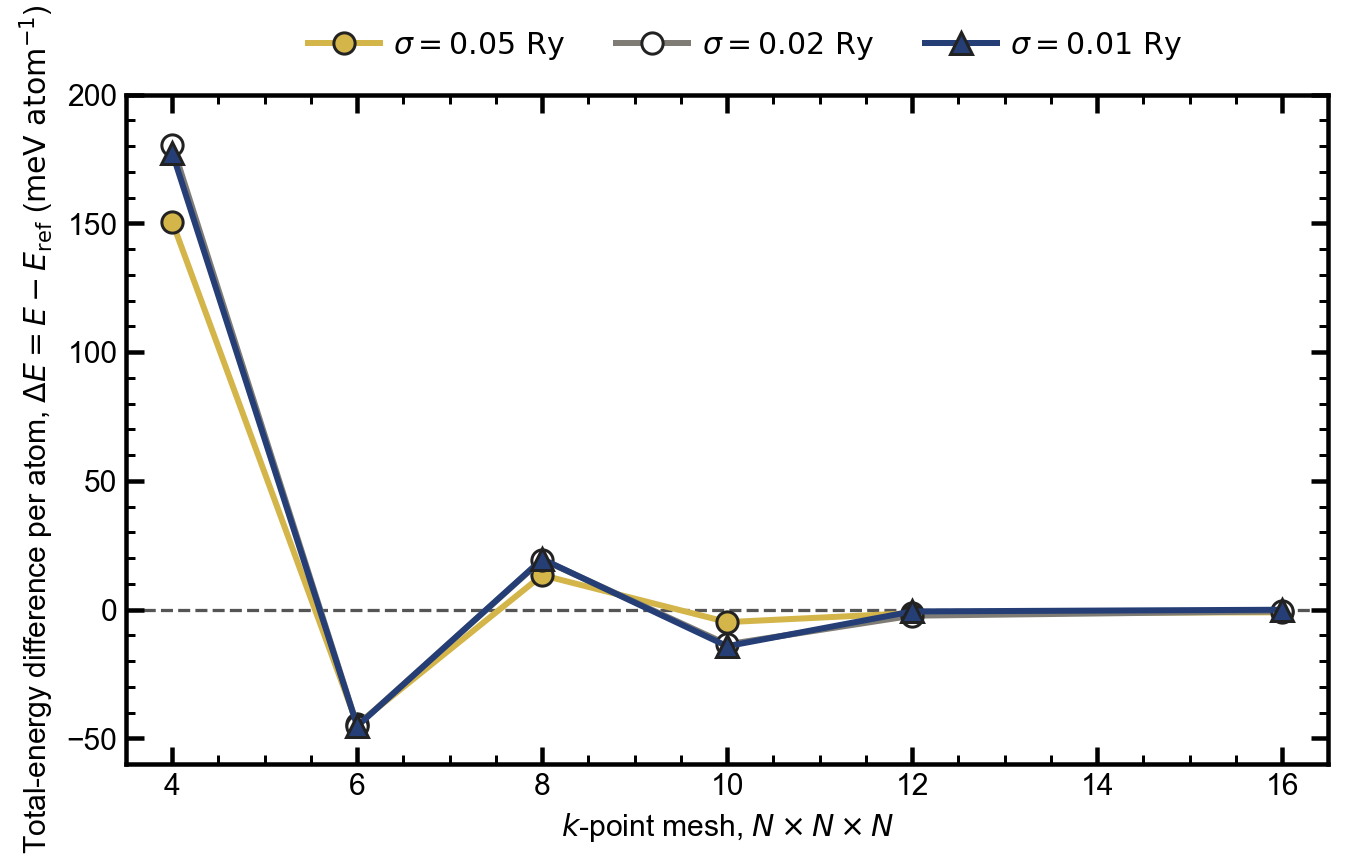

In [14]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import pandas as pd

# ---------- Data ----------
ROOT = Path.cwd()
if not (ROOT / "convergence-runs").exists():
    ROOT = Path("/Users/zhy/Aluminum-from-First-Principles")

df = pd.read_csv(ROOT / "convergence-runs/smearing/results.csv")

RY_TO_MEV = 13_605.693
ECUT = 35.0
KMESH_REF = 16
SIGMA_REF = 0.01

# All calculations use the one-atom fcc primitive cell.
# A single reference preserves the physically meaningful offsets
# between the three finite-smearing curves.
E_REF = df.loc[
    (df["ecutwfc_ry"] == ECUT)
    & (df["kmesh"] == KMESH_REF)
    & (df["degauss_ry"] == SIGMA_REF),
    "energy_ry",
].iloc[0]

plot_df = df[df["ecutwfc_ry"] == ECUT].copy()
plot_df["delta_e_mev_atom"] = (
    (plot_df["energy_ry"] - E_REF) * RY_TO_MEV
)

# ---------- Shared A2 figure style ----------
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.8,
    "savefig.dpi": 900,
})

# Stable, colorblind-considered palette for the project
GOLD = "#D3B54A"   # sigma = 0.05 Ry
GRAY = "#7E7C74"   # sigma = 0.02 Ry
NAVY = "#253E75"   # sigma = 0.01 Ry
EDGE = "#222222"

styles = {
    0.05: dict(color=GOLD, marker="o", mfc=GOLD, mec=EDGE,
               label=r"$\sigma = 0.05~\mathrm{Ry}$"),
    0.02: dict(color=GRAY, marker="o", mfc="white", mec=EDGE,
               label=r"$\sigma = 0.02~\mathrm{Ry}$"),
    0.01: dict(color=NAVY, marker="^", mfc=NAVY, mec=EDGE,
               label=r"$\sigma = 0.01~\mathrm{Ry}$"),
}

# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(8, 6))
fig.subplots_adjust(left=0.15, right=0.985, bottom=0.18, top=0.80)

for sigma in (0.05, 0.02, 0.01):
    subset = plot_df[plot_df["degauss_ry"] == sigma].sort_values("kmesh")
    style = styles[sigma]

    ax.plot(
        subset["kmesh"],
        subset["delta_e_mev_atom"],
        lw=2.4,
        ms=8.5,
        mew=1.2,
        zorder=3,
        **style,
    )

ax.axhline(0, color="#555555", lw=1.3, ls="--", zorder=1)

ax.set_xlim(3.5, 16.5)
ax.set_ylim(-60, 200)

ax.set_xticks([4, 6, 8, 10, 12, 14, 16])
ax.set_yticks([-50, 0, 50, 100, 150, 200])

ax.xaxis.set_minor_locator(MultipleLocator(0.5))
ax.yaxis.set_minor_locator(MultipleLocator(10))

ax.tick_params(which="both", direction="in", top=True, right=True)
ax.tick_params(which="major", length=7, width=1.8)
ax.tick_params(which="minor", length=3.5, width=1.2)

ax.set_xlabel(r"$k$-point mesh, $N \times N \times N$")
ax.set_ylabel(
    r"Total-energy difference per atom, "
    r"$\Delta E = E-E_{\mathrm{ref}}$ ($\mathrm{meV\ atom^{-1}}$)"
)

handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.58, 0.885),
    ncol=3,
    frameon=False,
    handlelength=2.4,
    columnspacing=1.7,
    handletextpad=0.45,
)

fig.savefig("A2_smearing_kpoint_convergence.png", dpi=900, bbox_inches="tight")
plt.show()

In [7]:
from pathlib import Path
import re
import pandas as pd

# Locate the project if the notebook was launched elsewhere
ROOT = Path.cwd()
if not (ROOT / "convergence-runs").exists():
    ROOT = Path("/Users/zhy/Aluminum-from-First-Principles")

RY_TO_MEV = 13_605.693  # 1 Ry = 13.605693 eV
N_ATOMS = 1             # fcc primitive cell used here contains one Al atom

cutoff = pd.read_csv(ROOT / "convergence-runs/cutoff-kmesh/results.csv")
smear = pd.read_csv(ROOT / "convergence-runs/smearing/results.csv")

def energy(df, ecut, kmesh, degauss):
    row = df[
        (df["ecutwfc_ry"] == ecut)
        & (df["kmesh"] == kmesh)
        & (df["degauss_ry"] == degauss)
    ]
    if len(row) != 1:
        raise ValueError(f"Expected one result for {ecut=}, {kmesh=}, {degauss=}; found {len(row)}.")
    return row["energy_ry"].iloc[0]

# Cutoff check: 35 Ry against the 40 Ry reference at 16 x 16 x 16 and degauss = 0.05 Ry
dE_cutoff = abs(
    energy(cutoff, 35, 16, 0.05) - energy(cutoff, 40, 16, 0.05)
) * RY_TO_MEV / N_ATOMS

# Mesh checks at the selected cutoff, comparing 12^3 with the finest tested 16^3 mesh
mesh_checks = {}
for sigma in (0.05, 0.02, 0.01):
    mesh_checks[sigma] = abs(
        energy(smear, 35, 12, sigma) - energy(smear, 35, 16, sigma)
    ) * RY_TO_MEV / N_ATOMS

# Smearing sensitivity at the selected 16^3 mesh
dE_smearing = abs(
    energy(smear, 35, 16, 0.01) - energy(smear, 35, 16, 0.05)
) * RY_TO_MEV / N_ATOMS

# Count calculations and extract QE timing summaries from completed outputs
output_files = sorted(ROOT.glob("convergence-runs/**/Al.scf.out"))
timing_pattern = re.compile(
    r"PWSCF\s*:\s*([0-9.]+)s CPU\s*([0-9.]+)s WALL"
)

cpu_seconds, wall_seconds = 0.0, 0.0
for output_file in output_files:
    match = timing_pattern.search(output_file.read_text(errors="replace"))
    if match is None:
        raise RuntimeError(f"No PWSCF timing line found in: {output_file}")
    cpu_seconds += float(match.group(1))
    wall_seconds += float(match.group(2))

print(f"Cutoff check, |E(35)-E(40)| at 16^3: {dE_cutoff:.3f} meV/atom")
for sigma, value in mesh_checks.items():
    print(f"Mesh check, |E(12^3)-E(16^3)| at σ={sigma:.2f} Ry: {value:.3f} meV/atom")
print(f"Smearing check, |E(σ=0.01)-E(σ=0.05)| at 16^3: {dE_smearing:.3f} meV/atom")

print(f"\nCutoff × k-mesh SCFs: {len(cutoff)}")
print(f"Smearing × k-mesh SCFs: {len(smear)}")
print(f"Total SCFs: {len(cutoff) + len(smear)}")
print(f"QE-reported total CPU time: {cpu_seconds:.2f} s ({cpu_seconds / 60:.2f} CPU min)")
print(f"QE-reported total wall time: {wall_seconds:.2f} s")

Cutoff check, |E(35)-E(40)| at 16^3: 0.856 meV/atom
Mesh check, |E(12^3)-E(16^3)| at σ=0.05 Ry: 0.317 meV/atom
Mesh check, |E(12^3)-E(16^3)| at σ=0.02 Ry: 1.714 meV/atom
Mesh check, |E(12^3)-E(16^3)| at σ=0.01 Ry: 0.664 meV/atom
Smearing check, |E(σ=0.01)-E(σ=0.05)| at 16^3: 1.003 meV/atom

Cutoff × k-mesh SCFs: 48
Smearing × k-mesh SCFs: 18
Total SCFs: 66
QE-reported total CPU time: 61.33 s (1.02 CPU min)
QE-reported total wall time: 66.06 s


I use $E_\mathrm{cut}=35~\mathrm{Ry}$, $E_\rho=280~\mathrm{Ry}$, a $16\times16\times16$ mesh, and $\sigma=0.01~\mathrm{Ry}$. At $16^3$, increasing the cutoff from 35 to $40~\mathrm{Ry}$ changes the total energy by only $0.856~\mathrm{meV\,atom^{-1}}$, below the $2~\mathrm{meV\,atom^{-1}}$ tolerance. The $12^3$-to-$16^3$ change is below $2~\mathrm{meV\,atom^{-1}}$ for every tested smearing, but $16^3$ is retained as the conservative finest tested mesh; $\sigma=0.01~\mathrm{Ry}$ is the smallest tested smearing and is within $1.003~\mathrm{meV\,atom^{-1}}$ of the $0.05~\mathrm{Ry}$ result at $16^3$. This choice was established using 66 SCF calculations (48 cutoff–mesh plus 18 smearing–mesh), totaling $61.33~\mathrm{s}$ of QE-reported CPU time.

A3. (a)

Begin final coordinates

     new unit-cell volume =    109.89829 a.u.^3 (    16.28525 Ang^3 )

     density =      2.75124 g/cm^3

CELL_PARAMETERS (alat=  9.00000000)

  -0.422419996  -0.000000000   0.422419996

   0.000000000   0.422419996   0.422419996

  -0.422419996   0.422419996  -0.000000000

ATOMIC_POSITIONS (alat)

Al               0.0000000000        0.0000000000        0.0000000000

End final coordinates




     Writing config-only to output data dir /Users/zhy/Aluminum-from-First-Principles/qe-out/a3-relax/
     aluminum_relax.save/ :

     XML data file

     Final scf calculation at the relaxed structure.

     The G-vectors are recalculated for the final unit cell

     Results may differ from those at the preceding step.

     Parallelization info

     --------------------

     sticks:   dense  smooth     PW     G-vecs:    dense   smooth      PW

     Min         279     141     48                 4327     1559     322

     Max         280     142     49                 4330     1560     323

     Sum         559     283     97                 8657     3119     645

     Using Slab Decomposition



     bravais-lattice index     =            2

     lattice parameter (alat)  =       9.0000  a.u.

     unit-cell volume          =     109.8983 (a.u.)^3

     number of atoms/cell      =            1

     number of atomic types    =            1

     number of electrons       =         3.00
     
     number of Kohn-Sham states=            6

In [ ]:
#!/usr/bin/env python3
"""Generate and optionally run fixed-volume fcc-Al SCFs for an EOS fit.

The default grid has twenty volumes from -8% to +8% around the relaxed
one-atom fcc primitive-cell volume.  Quantum ESPRESSO is launched only when
``--run`` is supplied; otherwise this script only writes the inputs and CSV
manifest.
"""

from __future__ import annotations

import argparse
import csv
import math
import re
import subprocess
from dataclasses import dataclass
from pathlib import Path


PROJECT_ROOT = Path(__file__).resolve().parents[1]
DEFAULT_PW = PROJECT_ROOT / ".qe" / "bin" / "pw.x"
DEFAULT_MPI = Path("/opt/homebrew/bin/mpirun")
DEFAULT_PSEUDO = PROJECT_ROOT / "Al.pbe-n-van.UPF"
DEFAULT_RUNS_DIR = PROJECT_ROOT / "eos-runs"

# A2 convergence settings.
ECUTWFC_RY = 35.0
ECUTRHO_RY = 280.0
KMESH = 16
DEGAUSS_RY = 0.01

# From the completed vc-relax: one fcc primitive cell with one Al atom.
RELAXED_VOLUME_BOHR3 = 109.89829
BOHR_TO_ANGSTROM = 0.529177210903

FINAL_ENERGY_RE = re.compile(
    r"^\s*!\s+total\s+energy\s*=\s*"
    r"([-+]?(?:\d+\.\d*|\d*\.\d+|\d+)(?:[EeDd][-+]?\d+)?)\s+Ry",
    re.MULTILINE,
)
FINAL_PRESSURE_RE = re.compile(
    r"\bP=\s*([-+]?(?:\d+\.\d*|\d*\.\d+|\d+)(?:[EeDd][-+]?\d+)?)"
)


@dataclass(frozen=True)
class EOSPoint:
    """One fixed-volume SCF calculation for the equation of state."""

    scale: float
    volume_bohr3: float

    @property
    def alat_bohr(self) -> float:
        # V_primitive = a_conventional^3 / 4 for fcc Al.
        return (4.0 * self.volume_bohr3) ** (1.0 / 3.0)

    @property
    def tag(self) -> str:
        return f"scale-{self.scale:.4f}_volume-{self.volume_bohr3:09.4f}-bohr3"

    @property
    def prefix(self) -> str:
        return f"aluminum_eos_{self.tag.replace('.', 'p')}"


def make_input(point: EOSPoint, pseudo: Path, scratch_dir: Path) -> str:
    """Return a self-contained fixed-volume SCF input."""

    return f"""&CONTROL
  calculation = 'scf',
  restart_mode = 'from_scratch',
  prefix = '{point.prefix}',
  tstress = .true.,
  tprnfor = .true.,
  pseudo_dir = '{pseudo.parent.resolve().as_posix()}/',
  outdir = '{scratch_dir.resolve().as_posix()}/'
/
&SYSTEM
  ibrav = 2,
  celldm(1) = {point.alat_bohr:.10f},
  nat = 1,
  ntyp = 1,
  ecutwfc = {ECUTWFC_RY:.1f},
  ecutrho = {ECUTRHO_RY:.1f},
  occupations = 'smearing',
  smearing = 'methfessel-paxton',
  degauss = {DEGAUSS_RY:.2f}
/
&ELECTRONS
  diagonalization = 'david',
  mixing_mode = 'plain',
  conv_thr = 1.0d-8
/
ATOMIC_SPECIES
  Al  26.982  {pseudo.name}
ATOMIC_POSITIONS alat
  Al  0.00  0.00  0.00
K_POINTS automatic
  {KMESH} {KMESH} {KMESH}  0 0 0
"""


def parse_last(pattern: re.Pattern[str], contents: str, label: str) -> float:
    matches = list(pattern.finditer(contents))
    if not matches:
        raise ValueError(f"No {label} found in QE output")
    return float(matches[-1].group(1).replace("D", "E").replace("d", "e"))


def successful_result(output_path: Path) -> tuple[float, float] | None:
    """Read a reusable normally completed SCF result, if it exists."""

    if not output_path.is_file():
        return None
    contents = output_path.read_text(encoding="utf-8", errors="replace")
    if (
        "JOB DONE." not in contents
        or "convergence has been achieved" not in contents
        or "convergence NOT achieved" in contents
    ):
        return None
    try:
        return (
            parse_last(FINAL_ENERGY_RE, contents, "final total energy"),
            parse_last(FINAL_PRESSURE_RE, contents, "pressure"),
        )
    except ValueError:
        return None


def write_results(path: Path, rows: list[dict[str, object]]) -> None:
    fields = (
        "scale",
        "volume_bohr3",
        "volume_ang3",
        "alat_bohr",
        "alat_ang",
        "ecutwfc_ry",
        "ecutrho_ry",
        "kmesh",
        "degauss_ry",
        "status",
        "energy_ry",
        "pressure_kbar",
        "pressure_gpa",
        "input_path",
        "output_path",
        "note",
    )
    with path.open("w", newline="", encoding="utf-8") as stream:
        writer = csv.DictWriter(stream, fieldnames=fields)
        writer.writeheader()
        writer.writerows(rows)


def main() -> int:
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument(
        "--center-volume",
        type=float,
        default=RELAXED_VOLUME_BOHR3,
        help=f"Relaxed primitive-cell volume in bohr^3 (default: {RELAXED_VOLUME_BOHR3})",
    )
    parser.add_argument(
        "--span",
        type=float,
        default=0.08,
        help="Symmetric fractional volume range about the center (default: 0.08).",
    )
    parser.add_argument(
        "--npoints",
        type=int,
        default=20,
        help="Number of equally spaced volumes, at least 11 (default: 20).",
    )
    parser.add_argument("--runs-dir", type=Path, default=DEFAULT_RUNS_DIR)
    parser.add_argument("--pseudo", type=Path, default=DEFAULT_PSEUDO)
    parser.add_argument("--pw", type=Path, default=DEFAULT_PW)
    parser.add_argument("--mpi", type=Path, default=DEFAULT_MPI)
    parser.add_argument("--nproc", type=int, default=2)
    parser.add_argument("--run", action="store_true", help="Actually launch PWSCF.")
    parser.add_argument("--force", action="store_true", help="Rerun completed points.")
    args = parser.parse_args()

    if args.center_volume <= 0 or not math.isfinite(args.center_volume):
        parser.error("--center-volume must be positive and finite")
    if not 0 < args.span < 1 or not math.isfinite(args.span):
        parser.error("--span must be between 0 and 1")
    if args.npoints < 11:
        parser.error("--npoints must be at least 11")
    if args.nproc < 1:
        parser.error("--nproc must be at least 1")

    pseudo = args.pseudo.resolve()
    pw = args.pw.resolve()
    mpi = args.mpi.resolve()
    if not pseudo.is_file():
        parser.error(f"Pseudopotential not found: {pseudo}")
    if args.run and (not pw.is_file() or not mpi.is_file()):
        parser.error("QE executable or MPI launcher not found; check --pw and --mpi")

    scales = [
        1.0 - args.span + 2.0 * args.span * index / (args.npoints - 1)
        for index in range(args.npoints)
    ]
    points = [EOSPoint(scale, args.center_volume * scale) for scale in scales]
    runs_dir = args.runs_dir.resolve()
    runs_dir.mkdir(parents=True, exist_ok=True)

    print(
        f"EOS grid: {len(points)} volumes from {scales[0]:.3f} to {scales[-1]:.3f} "
        f"of {args.center_volume:.5f} bohr^3; QE runs only with --run."
    )

    rows: list[dict[str, object]] = []
    any_failed = False
    for point in points:
        run_dir = runs_dir / point.tag
        input_path = run_dir / "Al.scf.inp"
        output_path = run_dir / "Al.scf.out"
        scratch_dir = run_dir / "qe-out"
        run_dir.mkdir(parents=True, exist_ok=True)
        scratch_dir.mkdir(exist_ok=True)
        input_path.write_text(make_input(point, pseudo, scratch_dir), encoding="utf-8")

        result = None if args.force else successful_result(output_path)
        status, note = "generated", "QE not launched; add --run to execute this point."
        energy, pressure = None, None

        if result is not None:
            status, note = "cached", "Existing normally completed SCF output reused."
            energy, pressure = result
        elif args.run:
            command = [str(mpi), "-np", str(args.nproc), str(pw), "-in", input_path.name]
            with output_path.open("w", encoding="utf-8") as stream:
                completed = subprocess.run(
                    command,
                    cwd=run_dir,
                    stdout=stream,
                    stderr=subprocess.STDOUT,
                    check=False,
                )
            result = successful_result(output_path)
            if completed.returncode == 0 and result is not None:
                status, note = "success", ""
                energy, pressure = result
            else:
                status = "failed"
                note = f"QE exit code {completed.returncode}; inspect {output_path}"
                any_failed = True

        rows.append({
            "scale": point.scale,
            "volume_bohr3": point.volume_bohr3,
            "volume_ang3": point.volume_bohr3 * BOHR_TO_ANGSTROM**3,
            "alat_bohr": point.alat_bohr,
            "alat_ang": point.alat_bohr * BOHR_TO_ANGSTROM,
            "ecutwfc_ry": ECUTWFC_RY,
            "ecutrho_ry": ECUTRHO_RY,
            "kmesh": KMESH,
            "degauss_ry": DEGAUSS_RY,
            "status": status,
            "energy_ry": "" if energy is None else energy,
            "pressure_kbar": "" if pressure is None else pressure,
            "pressure_gpa": "" if pressure is None else pressure * 0.1,
            "input_path": str(input_path),
            "output_path": str(output_path),
            "note": note,
        })

    result_path = runs_dir / "results.csv"
    write_results(result_path, rows)
    print(f"Wrote {result_path}")
    return 1 if any_failed else 0


if __name__ == "__main__":
    raise SystemExit(main())


In [15]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# ---------- Load completed EOS data ----------
ROOT = Path.cwd()
if not (ROOT / "eos-runs").exists():
    ROOT = Path("/Users/zhy/Aluminum-from-First-Principles")

raw = pd.read_csv(ROOT / "eos-runs" / "results.csv")

# Require a complete 20-point EOS dataset.
df = raw[raw["status"].isin(["success", "cached"])].copy()
if len(df) != 20:
    raise RuntimeError(
        f"Need 20 completed EOS SCFs; found {len(df)}. "
        "Check eos-runs/results.csv and failed outputs."
    )

for column in ("volume_bohr3", "alat_bohr", "energy_ry", "pressure_kbar", "output_path"):
    if df[column].isna().any():
        raise RuntimeError(f"Missing values in column: {column}")

df = df.sort_values("volume_bohr3").reset_index(drop=True)

# ---------- Physics audit: Vprimitive = alat^3 / 4 ----------
# The cell contains one atom in the fcc primitive cell.
volume_from_alat = df["alat_bohr"].to_numpy() ** 3 / 4.0
if not np.allclose(volume_from_alat, df["volume_bohr3"], rtol=0, atol=1e-8):
    raise RuntimeError("CSV volume and alat do not obey V = alat^3 / 4.")

# Independently check the volume printed by QE in every output file.
volume_pattern = re.compile(
    r"unit-cell volume\s*=\s*([-+0-9.EeDd]+)\s+\(a\.u\.\)\^3"
)

def final_printed_volume(output_path):
    text = Path(output_path).read_text(errors="replace")
    matches = volume_pattern.findall(text)
    if not matches:
        raise RuntimeError(f"Could not find QE cell volume in {output_path}")
    return float(matches[-1].replace("D", "E").replace("d", "e"))

df["qe_volume_bohr3"] = [
    final_printed_volume(path) for path in df["output_path"]
]
max_volume_difference = np.max(
    np.abs(df["qe_volume_bohr3"] - df["volume_bohr3"])
)
assert max_volume_difference < 5e-4, "QE-printed and CSV volumes disagree."

print(f"Volume audit passed; largest QE/CSV difference: "
      f"{max_volume_difference:.2e} bohr^3")

# ---------- Third-order Birch–Murnaghan EOS ----------
# QE's `! total energy` is F = E - TS at fixed degauss = 0.01 Ry.
# Fit this same quantity because QE pressure is -dF/dV at that smearing.
#
# The + sign before the quadratic term is essential.
RY_PER_BOHR3_TO_GPA = 14710.5078
RY_TO_MEV = 13605.693
BOHR_TO_ANG = 0.529177210903

def birch_murnaghan_energy(volume_bohr3, E0_ry, V0_bohr3, B0_gpa, B0_prime):
    x = (V0_bohr3 / volume_bohr3) ** (2.0 / 3.0)
    strain = x - 1.0
    B0_ry_per_bohr3 = B0_gpa / RY_PER_BOHR3_TO_GPA

    return E0_ry + (9.0 * V0_bohr3 * B0_ry_per_bohr3 / 16.0) * (
        strain**3 * B0_prime
        + strain**2 * (6.0 - 4.0 * x)
    )

def birch_murnaghan_pressure(volume_bohr3, V0_bohr3, B0_gpa, B0_prime):
    """Pressure in GPa; positive means compression."""
    ratio = V0_bohr3 / volume_bohr3
    x = ratio ** (2.0 / 3.0)

    return (3.0 * B0_gpa / 2.0) * (
        ratio ** (7.0 / 3.0) - ratio ** (5.0 / 3.0)
    ) * (
        1.0 + 3.0 * (B0_prime - 4.0) * (x - 1.0) / 4.0
    )

V = df["volume_bohr3"].to_numpy()
E = df["energy_ry"].to_numpy()
P_qe_gpa = 0.1 * df["pressure_kbar"].to_numpy()

minimum_index = np.argmin(E)
initial_guess = [
    E[minimum_index],  # E0, Ry
    V[minimum_index],  # V0, bohr^3/atom
    75.0,              # B0, GPa; sensible initial Al estimate
    4.0,               # B0', dimensionless
]

parameters, covariance = curve_fit(
    birch_murnaghan_energy,
    V,
    E,
    p0=initial_guess,
    bounds=(
        [E.min() - 1.0, 0.8 * V.min(), 1.0, 0.0],
        [E.min() + 1.0, 1.2 * V.max(), 200.0, 12.0],
    ),
    maxfev=100_000,
)

uncertainties = np.sqrt(np.diag(covariance))
E0, V0, B0_gpa, B0_prime = parameters
dE0, dV0, dB0_gpa, dB0_prime = uncertainties

# Convert fitted equilibrium primitive-cell volume to conventional fcc alat.
alat0_bohr = (4.0 * V0) ** (1.0 / 3.0)
alat0_ang = alat0_bohr * BOHR_TO_ANG
dalat0_bohr = alat0_bohr * dV0 / (3.0 * V0)
dalat0_ang = dalat0_bohr * BOHR_TO_ANG

V0_ang3 = V0 * BOHR_TO_ANG**3
dV0_ang3 = dV0 * BOHR_TO_ANG**3

print("\nThird-order Birch–Murnaghan fit, 1σ covariance uncertainties")
print(f"E0  = {E0:.9f} ± {dE0:.2e} Ry")
print(f"V0  = {V0:.5f} ± {dV0:.5f} bohr³/atom")
print(f"    = {V0_ang3:.5f} ± {dV0_ang3:.5f} Å³/atom")
print(f"a0  = {alat0_bohr:.5f} ± {dalat0_bohr:.5f} bohr")
print(f"    = {alat0_ang:.5f} ± {dalat0_ang:.5f} Å")
print(f"B0  = {B0_gpa:.3f} ± {dB0_gpa:.3f} GPa")
print(f"B0′ = {B0_prime:.3f} ± {dB0_prime:.3f}")

# ---------- Fit diagnostics ----------
E_fit = birch_murnaghan_energy(V, *parameters)
P_fit_gpa = birch_murnaghan_pressure(V, V0, B0_gpa, B0_prime)

energy_residual_mev = (E - E_fit) * RY_TO_MEV
pressure_residual_gpa = P_qe_gpa - P_fit_gpa

print(f"\nEnergy-fit RMS residual: "
      f"{np.sqrt(np.mean(energy_residual_mev**2)):.4f} meV/atom")
print(f"Pressure-fit RMS residual: "
      f"{np.sqrt(np.mean(pressure_residual_gpa**2)):.4f} GPa")
print(f"Relaxation-center difference: "
      f"{100 * (V0 / 109.89829 - 1):+.3f}%")

if not (V.min() < V0 < V.max()):
    raise RuntimeError("Fitted V0 lies outside the sampled-volume range.")
if B0_gpa <= 0:
    raise RuntimeError("Unphysical negative bulk modulus.")

correlation = covariance / np.outer(uncertainties, uncertainties)
print("\nParameter-correlation matrix:")
display(pd.DataFrame(
    correlation,
    index=[r"$E_0$", r"$V_0$", r"$B_0$", r"$B_0^\prime$"],
    columns=[r"$E_0$", r"$V_0$", r"$B_0$", r"$B_0^\prime$"],
).round(3))

Volume audit passed; largest QE/CSV difference: 4.68e-05 bohr^3

Third-order Birch–Murnaghan fit, 1σ covariance uncertainties
E0  = -12.466748533 ± 4.47e-07 Ry
V0  = 110.00749 ± 0.00277 bohr³/atom
    = 16.30143 ± 0.00041 Å³/atom
a0  = 7.60608 ± 0.00006 bohr
    = 4.02496 ± 0.00003 Å
B0  = 79.926 ± 0.039 GPa
B0′ = 4.788 ± 0.033

Energy-fit RMS residual: 0.0161 meV/atom
Pressure-fit RMS residual: 0.1553 GPa
Relaxation-center difference: +0.099%

Parameter-correlation matrix:


,$E_0$,$V_0$,$B_0$,$B_0^\prime$
$E_0$,1.000,-0.090,-0.745,0.168
$V_0$,-0.090,1.000,0.104,-0.909
$B_0$,-0.745,0.104,1.000,-0.258
$B_0^\prime$,0.168,-0.909,-0.258,1.000


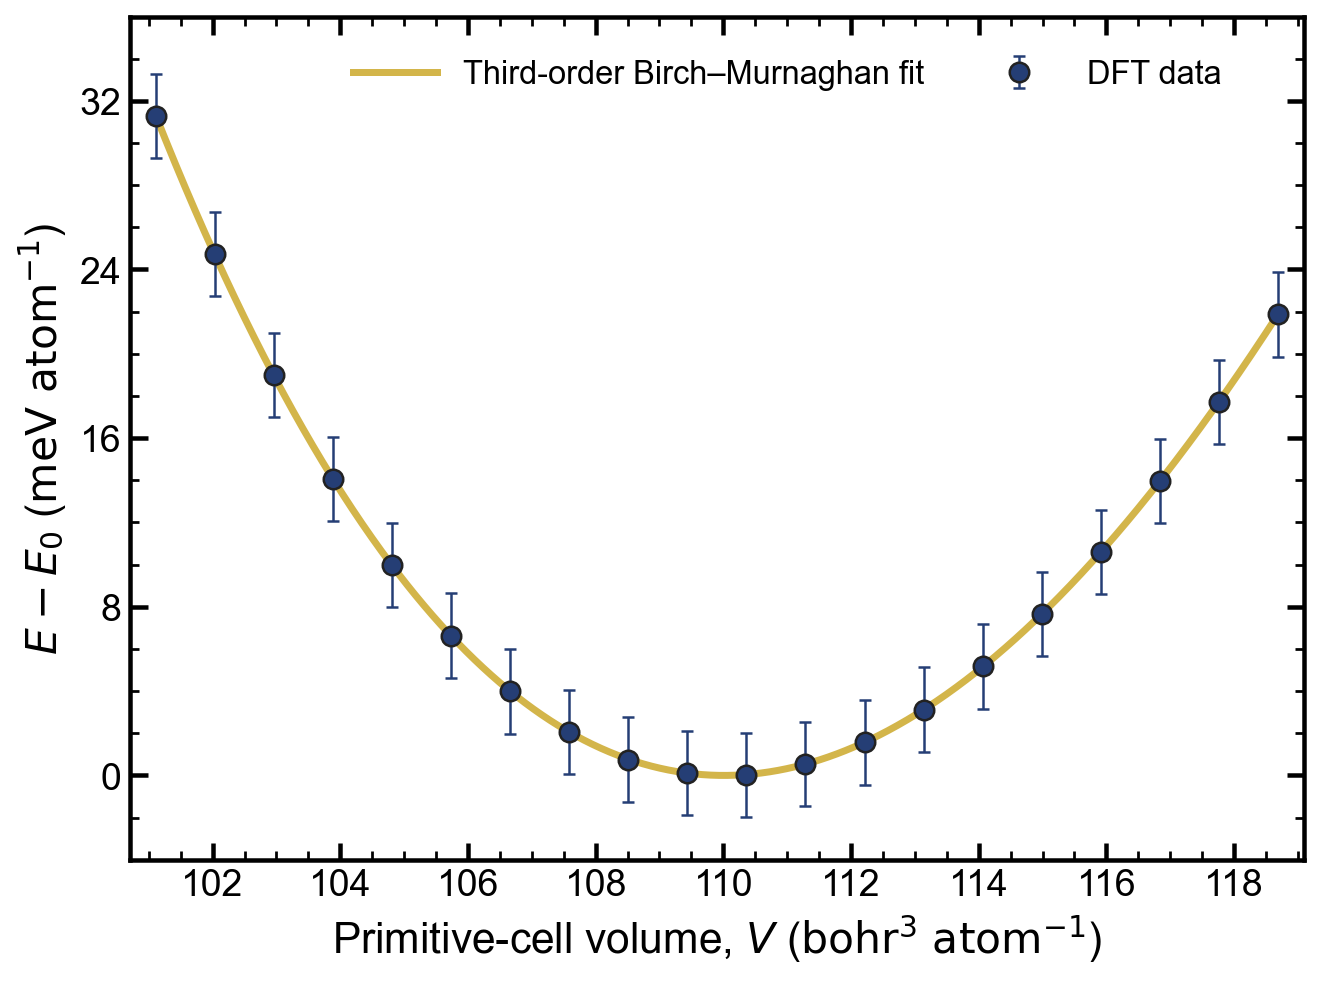

DFT total-energy differences for fcc Al versus primitive-cell volume (circles; vertical bars: $2~\mathrm{meV\,atom^{-1}}$ convergence tolerance) and third-order Birch–Murnaghan fit (line). $V_0=16.301\pm0.000~\mathrm{\AA^3\,atom^{-1}}$, $B_0=79.93\pm0.04~\mathrm{GPa}$, and $B_0^\prime=4.79\pm0.03$ (covariance-derived $1\sigma$ uncertainties).

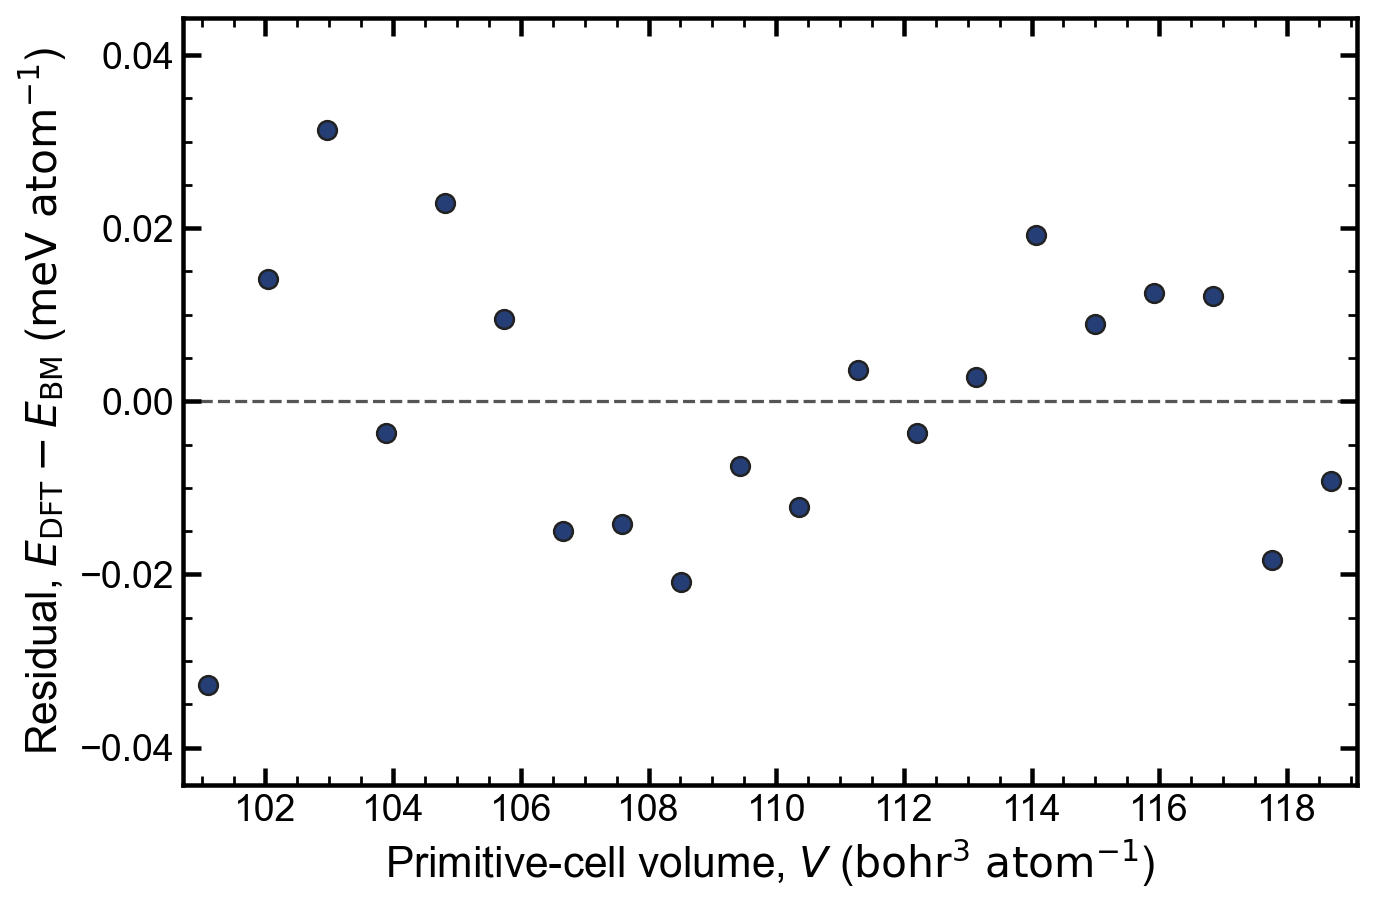

Residuals of the third-order Birch–Murnaghan fit. The dashed line denotes zero residual.

In [22]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MaxNLocator, MultipleLocator
from IPython.display import Markdown, display
import numpy as np

# Requires the completed fit cell:
# df, E0, V0, B0_gpa, B0_prime, dV0_ang3, V0_ang3,
# dB0_gpa, dB0_prime, RY_TO_MEV, birch_murnaghan_energy

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 15,
    "axes.labelsize": 17,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "axes.linewidth": 1.8,
    "savefig.dpi": 900,
})

GOLD = "#D3B54A"
NAVY = "#253E75"
GRAY = "#555555"
EDGE = "#222222"

ENERGY_TOLERANCE_MEV = 2.0

V = df["volume_bohr3"].to_numpy()
E = df["energy_ry"].to_numpy()

V_smooth = np.linspace(V.min(), V.max(), 800)
E_fit = birch_murnaghan_energy(V, E0, V0, B0_gpa, B0_prime)
E_smooth = birch_murnaghan_energy(V_smooth, E0, V0, B0_gpa, B0_prime)

E_data_mev = (E - E0) * RY_TO_MEV
E_fit_mev = (E_fit - E0) * RY_TO_MEV
E_smooth_mev = (E_smooth - E0) * RY_TO_MEV
residual_mev = (E - E_fit) * RY_TO_MEV

x_limits = (V.min() - 0.4, V.max() + 0.4)

# ============================================================
# Figure 1: E(V) and Birch–Murnaghan fit
# ============================================================
fig1, ax1 = plt.subplots(figsize=(8, 6))
fig1.subplots_adjust(left=0.17, right=0.985, bottom=0.18, top=0.96)

ax1.errorbar(
    V, E_data_mev,
    yerr=ENERGY_TOLERANCE_MEV,
    fmt="o",
    ms=7.8,
    mfc=NAVY,
    mec=EDGE,
    mew=1.0,
    ecolor=NAVY,
    elinewidth=1.0,
    capsize=2.4,
    linestyle="none",
    zorder=3,
    label="DFT data",
)

ax1.plot(
    V_smooth, E_smooth_mev,
    color=GOLD,
    lw=2.8,
    zorder=2,
    label="Third-order Birch–Murnaghan fit",
)

ax1.set_xlim(*x_limits)
ax1.set_ylim(
    -4,
    1.08 * max(
        np.max(E_data_mev + ENERGY_TOLERANCE_MEV),
        np.max(E_smooth_mev),
    ),
)

ax1.set_xlabel(
    r"Primitive-cell volume, $V$ "
    r"($\mathrm{bohr^3\ atom^{-1}}$)"
)
ax1.set_ylabel(r"$E-E_0$ ($\mathrm{meV\ atom^{-1}}$)")

ax1.xaxis.set_major_locator(MultipleLocator(2))
ax1.xaxis.set_minor_locator(MultipleLocator(0.5))
ax1.yaxis.set_major_locator(MaxNLocator(nbins=5))
ax1.yaxis.set_minor_locator(AutoMinorLocator(4))

ax1.tick_params(which="both", direction="in", top=True, right=True)
ax1.tick_params(which="major", length=7, width=1.8)
ax1.tick_params(which="minor", length=3.5, width=1.1)

ax1.legend(
    loc="upper center",
    bbox_to_anchor=(0.56, 0.985),
    ncol=2,
    frameon=False,
    fontsize=13,
    handlelength=2.6,
    columnspacing=1.6,
)

fig1.savefig(
    "A3_EOS_energy_fit.png",
    dpi=900,
    bbox_inches="tight",
    pad_inches=0.04,
)
plt.show()

caption_energy = (
    rf"DFT total-energy differences for fcc Al versus primitive-cell volume "
    rf"(circles; vertical bars: $2~\mathrm{{meV\,atom^{{-1}}}}$ convergence tolerance) "
    rf"and third-order Birch–Murnaghan fit (line). "
    rf"$V_0={V0_ang3:.3f}\pm{dV0_ang3:.3f}~\mathrm{{\AA^3\,atom^{{-1}}}}$, "
    rf"$B_0={B0_gpa:.2f}\pm{dB0_gpa:.2f}~\mathrm{{GPa}}$, and "
    rf"$B_0^\prime={B0_prime:.2f}\pm{dB0_prime:.2f}$ "
    rf"(covariance-derived $1\sigma$ uncertainties)."
)
display(Markdown(caption_energy))

# ============================================================
# Figure 2: residuals
# ============================================================
fig2, ax2 = plt.subplots(figsize=(8, 6))
fig2.subplots_adjust(left=0.17, right=0.985, bottom=0.24, top=0.95)

ax2.axhline(0, color=GRAY, lw=1.3, ls="--", zorder=1)
ax2.plot(
    V, residual_mev,
    linestyle="none",
    marker="o",
    ms=7.5,
    mfc=NAVY,
    mec=EDGE,
    mew=1.0,
    zorder=3,
)

residual_limit = max(0.01, 1.35 * np.max(np.abs(residual_mev)))
ax2.set_xlim(*x_limits)
ax2.set_ylim(-residual_limit, residual_limit)

ax2.set_xlabel(
    r"Primitive-cell volume, $V$ "
    r"($\mathrm{bohr^3\ atom^{-1}}$)"
)
ax2.set_ylabel(r"Residual, $E_{\mathrm{DFT}}-E_{\mathrm{BM}}$ "
               r"($\mathrm{meV\ atom^{-1}}$)")

ax2.xaxis.set_major_locator(MultipleLocator(2))
ax2.xaxis.set_minor_locator(MultipleLocator(0.5))
ax2.yaxis.set_major_locator(MaxNLocator(nbins=5))
ax2.yaxis.set_minor_locator(AutoMinorLocator(4))

ax2.tick_params(which="both", direction="in", top=True, right=True)
ax2.tick_params(which="major", length=7, width=1.8)
ax2.tick_params(which="minor", length=3.5, width=1.1)

fig2.savefig(
    "A3_EOS_fit_residuals.png",
    dpi=900,
    bbox_inches="tight",
    pad_inches=0.04,
)
plt.show()

display(Markdown(
    r"Residuals of the third-order Birch–Murnaghan fit. "
    r"The dashed line denotes zero residual."
))

In [ ]:
#!/usr/bin/env python3
"""Prepare and optionally run the LDA Al convergence and EOS workflow.

This is deliberately safe by default: it writes inputs and manifests, but starts
Quantum ESPRESSO only when ``--run`` is supplied.  All LDA data live in
directories separate from the completed PBE A2/A3 workflow.

Workflow
--------
1. Briefly recheck cutoff, k mesh, and smearing with ``convergence``.
2. Run a short LDA ``vc-relax`` from a sensible starting lattice constant.
3. Generate/run a 20-point, +/-8 percent fixed-volume EOS around that result.

The supplied Al.pz-vbc.UPF is PZ-LDA and norm-conserving, so this driver uses
ecutrho = 4 * ecutwfc (rather than the 8x ratio used for the PBE ultrasoft PP).
"""

from __future__ import annotations

import argparse
import csv
import math
import re
import subprocess
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable


PROJECT_ROOT = Path(__file__).resolve().parents[1]
DEFAULT_PW = PROJECT_ROOT / ".qe" / "bin" / "pw.x"
DEFAULT_MPI = Path("/opt/homebrew/bin/mpirun")
DEFAULT_PSEUDO = PROJECT_ROOT / "Al.pz-vbc.UPF"
DEFAULT_CONV_DIR = PROJECT_ROOT / "lda-convergence-runs"
DEFAULT_RELAX_DIR = PROJECT_ROOT / "lda-a3-relax"
DEFAULT_EOS_DIR = PROJECT_ROOT / "lda-eos-runs"

# A near-equilibrium starting point for fcc Al, used only for the brief check.
CONVERGENCE_ALAT_BOHR = 7.60
STARTING_ALAT_BOHR = 7.60
DEFAULT_DEGAUSS_RY = 0.01
ECUTRHO_RATIO_NC = 4.0
CUTOFFS_RY = (40.0, 50.0, 60.0, 70.0, 80.0)
KMESHES = (12, 16, 20)
SMEARINGS_RY = (0.05, 0.02, 0.01)
BOHR_TO_ANGSTROM = 0.529177210903
RY_TO_MEV = 13605.693122994

FINAL_ENERGY_RE = re.compile(
    r"^\s*!\s+total\s+energy\s*=\s*"
    r"([-+]?(?:\d+\.\d*|\d*\.\d+|\d+)(?:[EeDd][-+]?\d+)?)\s+Ry",
    re.MULTILINE,
)
FINAL_PRESSURE_RE = re.compile(
    r"\bP=\s*([-+]?(?:\d+\.\d*|\d*\.\d+|\d+)(?:[EeDd][-+]?\d+)?)"
)
FINAL_VOLUME_RE = re.compile(
    r"new\s+unit-cell\s+volume\s*=\s*"
    r"([-+]?(?:\d+\.\d*|\d*\.\d+|\d+)(?:[EeDd][-+]?\d+)?)\s+a\.u\.\^3",
    re.IGNORECASE,
)


@dataclass(frozen=True)
class Settings:
    """Numerical settings shared by a self-consistent calculation."""

    ecutwfc_ry: float
    kmesh: int
    degauss_ry: float
    ecutrho_ratio: float = ECUTRHO_RATIO_NC

    @property
    def ecutrho_ry(self) -> float:
        return self.ecutrho_ratio * self.ecutwfc_ry


@dataclass(frozen=True)
class EOSPoint:
    scale: float
    volume_bohr3: float

    @property
    def alat_bohr(self) -> float:
        # fcc primitive cell with one atom: V = a_conventional^3 / 4.
        return (4.0 * self.volume_bohr3) ** (1.0 / 3.0)

    @property
    def tag(self) -> str:
        return f"scale-{self.scale:.4f}_volume-{self.volume_bohr3:09.4f}-bohr3"


def ensure_run_environment(args: argparse.Namespace) -> tuple[Path, Path, Path]:
    pseudo = args.pseudo.resolve()
    pw = args.pw.resolve()
    mpi = args.mpi.resolve()
    if not pseudo.is_file():
        raise FileNotFoundError(f"Pseudopotential not found: {pseudo}")
    if args.run:
        missing = [
            str(path)
            for path in (pw, mpi)
            if not path.is_file() or not (path.stat().st_mode & 0o111)
        ]
        if missing:
            raise FileNotFoundError("Missing executable(s): " + ", ".join(missing))
    return pseudo, pw, mpi


def qe_input(
    *,
    calculation: str,
    prefix: str,
    alat_bohr: float,
    settings: Settings,
    pseudo: Path,
    scratch_dir: Path,
) -> str:
    """Render a self-contained fcc-Al QE input using the supplied PZ-LDA PP."""

    relaxation_blocks = "&IONS\n/\n&CELL\n/\n" if calculation == "vc-relax" else ""
    return f"""&CONTROL
  calculation = '{calculation}',
  restart_mode = 'from_scratch',
  prefix = '{prefix}',
  tstress = .true.,
  tprnfor = .true.,
  pseudo_dir = '{pseudo.parent.resolve().as_posix()}/',
  outdir = '{scratch_dir.resolve().as_posix()}/'
/
&SYSTEM
  ibrav = 2,
  celldm(1) = {alat_bohr:.10f},
  nat = 1,
  ntyp = 1,
  input_dft = 'PZ',
  ecutwfc = {settings.ecutwfc_ry:.6f},
  ecutrho = {settings.ecutrho_ry:.6f},
  occupations = 'smearing',
  smearing = 'methfessel-paxton',
  degauss = {settings.degauss_ry:.6f}
/
&ELECTRONS
  diagonalization = 'david',
  mixing_mode = 'plain',
  conv_thr = 1.0d-8
/
{relaxation_blocks}ATOMIC_SPECIES
  Al  26.982  {pseudo.name}
ATOMIC_POSITIONS alat
  Al  0.00  0.00  0.00
K_POINTS automatic
  {settings.kmesh} {settings.kmesh} {settings.kmesh}  0 0 0
"""


def parse_last(pattern: re.Pattern[str], text: str, name: str) -> float:
    matches = list(pattern.finditer(text))
    if not matches:
        raise ValueError(f"No {name} was found in QE output")
    return float(matches[-1].group(1).replace("D", "E").replace("d", "e"))


def completed_scf(output_path: Path) -> tuple[float, float] | None:
    """Return final energy and pressure only for normally converged SCFs."""

    if not output_path.is_file():
        return None
    text = output_path.read_text(encoding="utf-8", errors="replace")
    if (
        "JOB DONE." not in text
        or "convergence has been achieved" not in text
        or "convergence NOT achieved" in text
    ):
        return None
    try:
        return (
            parse_last(FINAL_ENERGY_RE, text, "final total energy"),
            parse_last(FINAL_PRESSURE_RE, text, "final pressure"),
        )
    except ValueError:
        return None


def completed_relax_volume(output_path: Path) -> float | None:
    """Return the final primitive-cell volume from a completed vc-relax."""

    if not output_path.is_file():
        return None
    text = output_path.read_text(encoding="utf-8", errors="replace")
    if "JOB DONE." not in text:
        return None
    try:
        return parse_last(FINAL_VOLUME_RE, text, "final unit-cell volume")
    except ValueError:
        return None


def launch_or_reuse(
    *,
    input_path: Path,
    output_path: Path,
    pw: Path,
    mpi: Path,
    nproc: int,
    run: bool,
    force: bool,
    result_reader,
) -> tuple[str, tuple[float, ...] | None, str]:
    """Use a valid existing result, or run QE only after explicit authorization."""

    result = None if force else result_reader(output_path)
    if result is not None:
        return "cached", result if isinstance(result, tuple) else (result,), "Existing completed output reused."
    if not run:
        return "generated", None, "QE not launched; add --run to execute this input."

    command = [str(mpi), "-np", str(nproc), str(pw), "-in", input_path.name]
    with output_path.open("w", encoding="utf-8") as stream:
        completed = subprocess.run(
            command,
            cwd=input_path.parent,
            stdout=stream,
            stderr=subprocess.STDOUT,
            check=False,
        )
    result = result_reader(output_path)
    if completed.returncode == 0 and result is not None:
        return "success", result if isinstance(result, tuple) else (result,), ""
    return "failed", None, f"QE exit code {completed.returncode}; inspect {output_path}"


def write_csv(path: Path, rows: Iterable[dict[str, object]], fields: tuple[str, ...]) -> None:
    with path.open("w", newline="", encoding="utf-8") as stream:
        writer = csv.DictWriter(stream, fieldnames=fields)
        writer.writeheader()
        writer.writerows(rows)


def validate_settings(settings: Settings) -> None:
    if settings.ecutwfc_ry <= 0 or settings.kmesh < 1 or settings.degauss_ry <= 0:
        raise ValueError("ecutwfc, kmesh, and degauss must all be positive")
    if settings.ecutrho_ratio < 4:
        raise ValueError("Use ecutrho / ecutwfc >= 4 for this norm-conserving workflow")


def settings_from_args(args: argparse.Namespace) -> Settings:
    settings = Settings(
        ecutwfc_ry=args.ecutwfc,
        kmesh=args.kmesh,
        degauss_ry=args.degauss,
        ecutrho_ratio=args.ecutrho_ratio,
    )
    validate_settings(settings)
    return settings


def convergence_specs(stage: str, args: argparse.Namespace) -> list[Settings]:
    if stage == "cutoff":
        return [Settings(ecut, 16, DEFAULT_DEGAUSS_RY, args.ecutrho_ratio) for ecut in CUTOFFS_RY]
    if args.ecutwfc is None:
        raise ValueError(f"convergence {stage} requires --ecutwfc after the cutoff check")
    if stage == "kmesh":
        return [Settings(args.ecutwfc, kmesh, DEFAULT_DEGAUSS_RY, args.ecutrho_ratio) for kmesh in KMESHES]
    if args.kmesh is None:
        raise ValueError("convergence smearing requires --kmesh after the k-mesh check")
    return [Settings(args.ecutwfc, args.kmesh, degauss, args.ecutrho_ratio) for degauss in SMEARINGS_RY]


def convergence_command(args: argparse.Namespace) -> int:
    pseudo, pw, mpi = ensure_run_environment(args)
    specs = convergence_specs(args.stage, args)
    root = args.runs_dir.resolve() / args.stage
    root.mkdir(parents=True, exist_ok=True)
    fields = (
        "stage", "ecutwfc_ry", "ecutrho_ry", "ecutrho_ratio", "kmesh", "degauss_ry",
        "alat_bohr", "status", "energy_ry", "pressure_kbar", "input_path", "output_path", "note",
    )
    rows: list[dict[str, object]] = []
    failed = False

    for settings in specs:
        validate_settings(settings)
        tag = (
            f"ecut-{settings.ecutwfc_ry:05.1f}-ry_"
            f"k-{settings.kmesh:02d}x{settings.kmesh:02d}x{settings.kmesh:02d}_"
            f"degauss-{settings.degauss_ry:.3f}-ry"
        )
        run_dir = root / tag
        run_dir.mkdir(parents=True, exist_ok=True)
        input_path = run_dir / "Al.scf.inp"
        output_path = run_dir / "Al.scf.out"
        scratch_dir = run_dir / "qe-out"
        scratch_dir.mkdir(exist_ok=True)
        input_path.write_text(
            qe_input(
                calculation="scf",
                prefix=f"lda_{args.stage}_{tag.replace('.', 'p')}",
                alat_bohr=CONVERGENCE_ALAT_BOHR,
                settings=settings,
                pseudo=pseudo,
                scratch_dir=scratch_dir,
            ),
            encoding="utf-8",
        )
        status, result, note = launch_or_reuse(
            input_path=input_path, output_path=output_path, pw=pw, mpi=mpi,
            nproc=args.nproc, run=args.run, force=args.force, result_reader=completed_scf,
        )
        failed = failed or status == "failed"
        energy, pressure = (result if result is not None else (None, None))
        rows.append({
            "stage": args.stage,
            "ecutwfc_ry": settings.ecutwfc_ry,
            "ecutrho_ry": settings.ecutrho_ry,
            "ecutrho_ratio": settings.ecutrho_ratio,
            "kmesh": settings.kmesh,
            "degauss_ry": settings.degauss_ry,
            "alat_bohr": CONVERGENCE_ALAT_BOHR,
            "status": status,
            "energy_ry": "" if energy is None else energy,
            "pressure_kbar": "" if pressure is None else pressure,
            "input_path": str(input_path),
            "output_path": str(output_path),
            "note": note,
        })
    manifest = root / "results.csv"
    write_csv(manifest, rows, fields)
    print(f"Wrote {manifest}. QE was {'launched' if args.run else 'not launched'}.")
    return 1 if failed else 0


def summarize_command(args: argparse.Namespace) -> int:
    path = args.runs_dir.resolve() / args.stage / "results.csv"
    if not path.is_file():
        raise FileNotFoundError(f"No convergence manifest: {path}")
    with path.open(newline="", encoding="utf-8") as stream:
        rows = [row for row in csv.DictReader(stream) if row["status"] in {"success", "cached"}]
    if not rows:
        raise RuntimeError("No completed convergence results yet.")
    for row in rows:
        row["energy_ry"] = float(row["energy_ry"])
    # For cutoff and kmesh, the largest value is the local reference.  For
    # smearing, use the smallest width, which is closest to the T -> 0 limit.
    if args.stage == "cutoff":
        reference = max(rows, key=lambda r: float(r["ecutwfc_ry"]))
        order = lambda r: float(r["ecutwfc_ry"])
        label = "ecutwfc (Ry)"
        value = lambda r: float(r["ecutwfc_ry"])
    elif args.stage == "kmesh":
        reference = max(rows, key=lambda r: int(r["kmesh"]))
        order = lambda r: int(r["kmesh"])
        label = "k mesh"
        value = lambda r: int(r["kmesh"])
    else:
        reference = min(rows, key=lambda r: float(r["degauss_ry"]))
        order = lambda r: float(r["degauss_ry"])
        label = "degauss (Ry)"
        value = lambda r: float(r["degauss_ry"])
    print(f"Reference: {label} = {value(reference)}; E = {reference['energy_ry']:.12f} Ry")
    print(f"{'parameter':>16s}  {'E (Ry)':>18s}  {'|Delta E| (meV/atom)':>23s}")
    for row in sorted(rows, key=order):
        error_mev = abs(row["energy_ry"] - reference["energy_ry"]) * RY_TO_MEV
        print(f"{str(value(row)):>16s}  {row['energy_ry']:18.12f}  {error_mev:23.6f}")
    print("Use the smallest setting that remains within the stated 2 meV/atom target;"
          " inspect the full trend rather than relying on one accidental cancellation.")
    return 0


def relax_command(args: argparse.Namespace) -> int:
    pseudo, pw, mpi = ensure_run_environment(args)
    settings = settings_from_args(args)
    root = args.relax_dir.resolve()
    root.mkdir(parents=True, exist_ok=True)
    input_path = root / "Al.relax.inp"
    output_path = root / "Al.relax.out"
    scratch_dir = root / "qe-out"
    scratch_dir.mkdir(exist_ok=True)
    input_path.write_text(
        qe_input(
            calculation="vc-relax", prefix="aluminum_lda_relax",
            alat_bohr=args.starting_alat, settings=settings, pseudo=pseudo, scratch_dir=scratch_dir,
        ),
        encoding="utf-8",
    )
    status, result, note = launch_or_reuse(
        input_path=input_path, output_path=output_path, pw=pw, mpi=mpi,
        nproc=args.nproc, run=args.run, force=args.force, result_reader=completed_relax_volume,
    )
    if result is None:
        print(f"LDA relaxation status: {status}. {note}")
        return 1 if status == "failed" else 0
    volume = result[0]
    alat = (4.0 * volume) ** (1.0 / 3.0)
    print(f"LDA relaxed primitive volume: {volume:.8f} bohr^3")
    print(f"LDA relaxed conventional fcc alat: {alat:.8f} bohr = {alat * BOHR_TO_ANGSTROM:.8f} Angstrom")
    print("The EOS command will use this volume automatically with --center-from-relax.")
    return 0


def eos_command(args: argparse.Namespace) -> int:
    pseudo, pw, mpi = ensure_run_environment(args)
    settings = settings_from_args(args)
    if args.npoints < 11:
        raise ValueError("Use at least 11 EOS volumes")
    if not 0 < args.span < 1:
        raise ValueError("--span must be between 0 and 1")
    if args.center_from_relax:
        center = completed_relax_volume(args.relax_dir.resolve() / "Al.relax.out")
        if center is None:
            raise RuntimeError("No completed LDA relaxation found; run `relax --run` first.")
    elif args.center_volume is not None:
        center = args.center_volume
    else:
        raise ValueError("Provide --center-from-relax or --center-volume")
    if center <= 0:
        raise ValueError("Center volume must be positive")

    scales = [1.0 - args.span + 2.0 * args.span * i / (args.npoints - 1) for i in range(args.npoints)]
    points = [EOSPoint(scale, center * scale) for scale in scales]
    root = args.eos_dir.resolve()
    root.mkdir(parents=True, exist_ok=True)
    fields = (
        "scale", "volume_bohr3", "volume_ang3", "alat_bohr", "alat_ang",
        "ecutwfc_ry", "ecutrho_ry", "kmesh", "degauss_ry", "status", "energy_ry",
        "pressure_kbar", "pressure_gpa", "input_path", "output_path", "note",
    )
    rows: list[dict[str, object]] = []
    failed = False
    for point in points:
        run_dir = root / point.tag
        run_dir.mkdir(parents=True, exist_ok=True)
        input_path = run_dir / "Al.scf.inp"
        output_path = run_dir / "Al.scf.out"
        scratch_dir = run_dir / "qe-out"
        scratch_dir.mkdir(exist_ok=True)
        input_path.write_text(
            qe_input(
                calculation="scf", prefix=f"aluminum_lda_eos_{point.tag.replace('.', 'p')}",
                alat_bohr=point.alat_bohr, settings=settings, pseudo=pseudo, scratch_dir=scratch_dir,
            ),
            encoding="utf-8",
        )
        status, result, note = launch_or_reuse(
            input_path=input_path, output_path=output_path, pw=pw, mpi=mpi,
            nproc=args.nproc, run=args.run, force=args.force, result_reader=completed_scf,
        )
        failed = failed or status == "failed"
        energy, pressure = (result if result is not None else (None, None))
        rows.append({
            "scale": point.scale,
            "volume_bohr3": point.volume_bohr3,
            "volume_ang3": point.volume_bohr3 * BOHR_TO_ANGSTROM**3,
            "alat_bohr": point.alat_bohr,
            "alat_ang": point.alat_bohr * BOHR_TO_ANGSTROM,
            "ecutwfc_ry": settings.ecutwfc_ry,
            "ecutrho_ry": settings.ecutrho_ry,
            "kmesh": settings.kmesh,
            "degauss_ry": settings.degauss_ry,
            "status": status,
            "energy_ry": "" if energy is None else energy,
            "pressure_kbar": "" if pressure is None else pressure,
            "pressure_gpa": "" if pressure is None else pressure * 0.1,
            "input_path": str(input_path),
            "output_path": str(output_path),
            "note": note,
        })
    manifest = root / "results.csv"
    write_csv(manifest, rows, fields)
    print(f"Wrote {manifest} for {len(points)} LDA EOS points about {center:.8f} bohr^3.")
    return 1 if failed else 0


def shared_arguments(parser: argparse.ArgumentParser) -> None:
    parser.add_argument("--pseudo", type=Path, default=DEFAULT_PSEUDO)
    parser.add_argument("--pw", type=Path, default=DEFAULT_PW)
    parser.add_argument("--mpi", type=Path, default=DEFAULT_MPI)
    parser.add_argument("--nproc", type=int, default=2)
    parser.add_argument("--run", action="store_true", help="Actually launch Quantum ESPRESSO.")
    parser.add_argument("--force", action="store_true", help="Rerun completed cases.")


def numerical_arguments(parser: argparse.ArgumentParser, *, required: bool) -> None:
    parser.add_argument("--ecutwfc", type=float, required=required)
    parser.add_argument("--kmesh", type=int, required=required)
    parser.add_argument("--degauss", type=float, default=DEFAULT_DEGAUSS_RY)
    parser.add_argument("--ecutrho-ratio", type=float, default=ECUTRHO_RATIO_NC)


def build_parser() -> argparse.ArgumentParser:
    parser = argparse.ArgumentParser(description=__doc__)
    commands = parser.add_subparsers(dest="command", required=True)

    convergence = commands.add_parser("convergence", help="Generate/run a brief LDA numerical recheck.")
    convergence.add_argument("stage", choices=("cutoff", "kmesh", "smearing"))
    convergence.add_argument("--runs-dir", type=Path, default=DEFAULT_CONV_DIR)
    convergence.add_argument("--ecutwfc", type=float)
    convergence.add_argument("--kmesh", type=int)
    convergence.add_argument("--ecutrho-ratio", type=float, default=ECUTRHO_RATIO_NC)
    shared_arguments(convergence)

    summary = commands.add_parser("summarize", help="Print convergence errors relative to the local reference.")
    summary.add_argument("stage", choices=("cutoff", "kmesh", "smearing"))
    summary.add_argument("--runs-dir", type=Path, default=DEFAULT_CONV_DIR)

    relax = commands.add_parser("relax", help="Generate/run an LDA vc-relax near the expected minimum.")
    relax.add_argument("--relax-dir", type=Path, default=DEFAULT_RELAX_DIR)
    relax.add_argument("--starting-alat", type=float, default=STARTING_ALAT_BOHR)
    numerical_arguments(relax, required=True)
    shared_arguments(relax)

    eos = commands.add_parser("eos", help="Generate/run the 20-point LDA fixed-volume EOS.")
    eos.add_argument("--eos-dir", type=Path, default=DEFAULT_EOS_DIR)
    eos.add_argument("--relax-dir", type=Path, default=DEFAULT_RELAX_DIR)
    eos.add_argument("--center-from-relax", action="store_true")
    eos.add_argument("--center-volume", type=float)
    eos.add_argument("--span", type=float, default=0.08)
    eos.add_argument("--npoints", type=int, default=20)
    numerical_arguments(eos, required=True)
    shared_arguments(eos)
    return parser


def main() -> int:
    parser = build_parser()
    args = parser.parse_args()
    if getattr(args, "nproc", 1) < 1:
        parser.error("--nproc must be at least 1")
    try:
        if args.command == "convergence":
            return convergence_command(args)
        if args.command == "summarize":
            return summarize_command(args)
        if args.command == "relax":
            return relax_command(args)
        return eos_command(args)
    except (FileNotFoundError, RuntimeError, ValueError) as error:
        parser.error(str(error))
    return 2


if __name__ == "__main__":
    raise SystemExit(main())


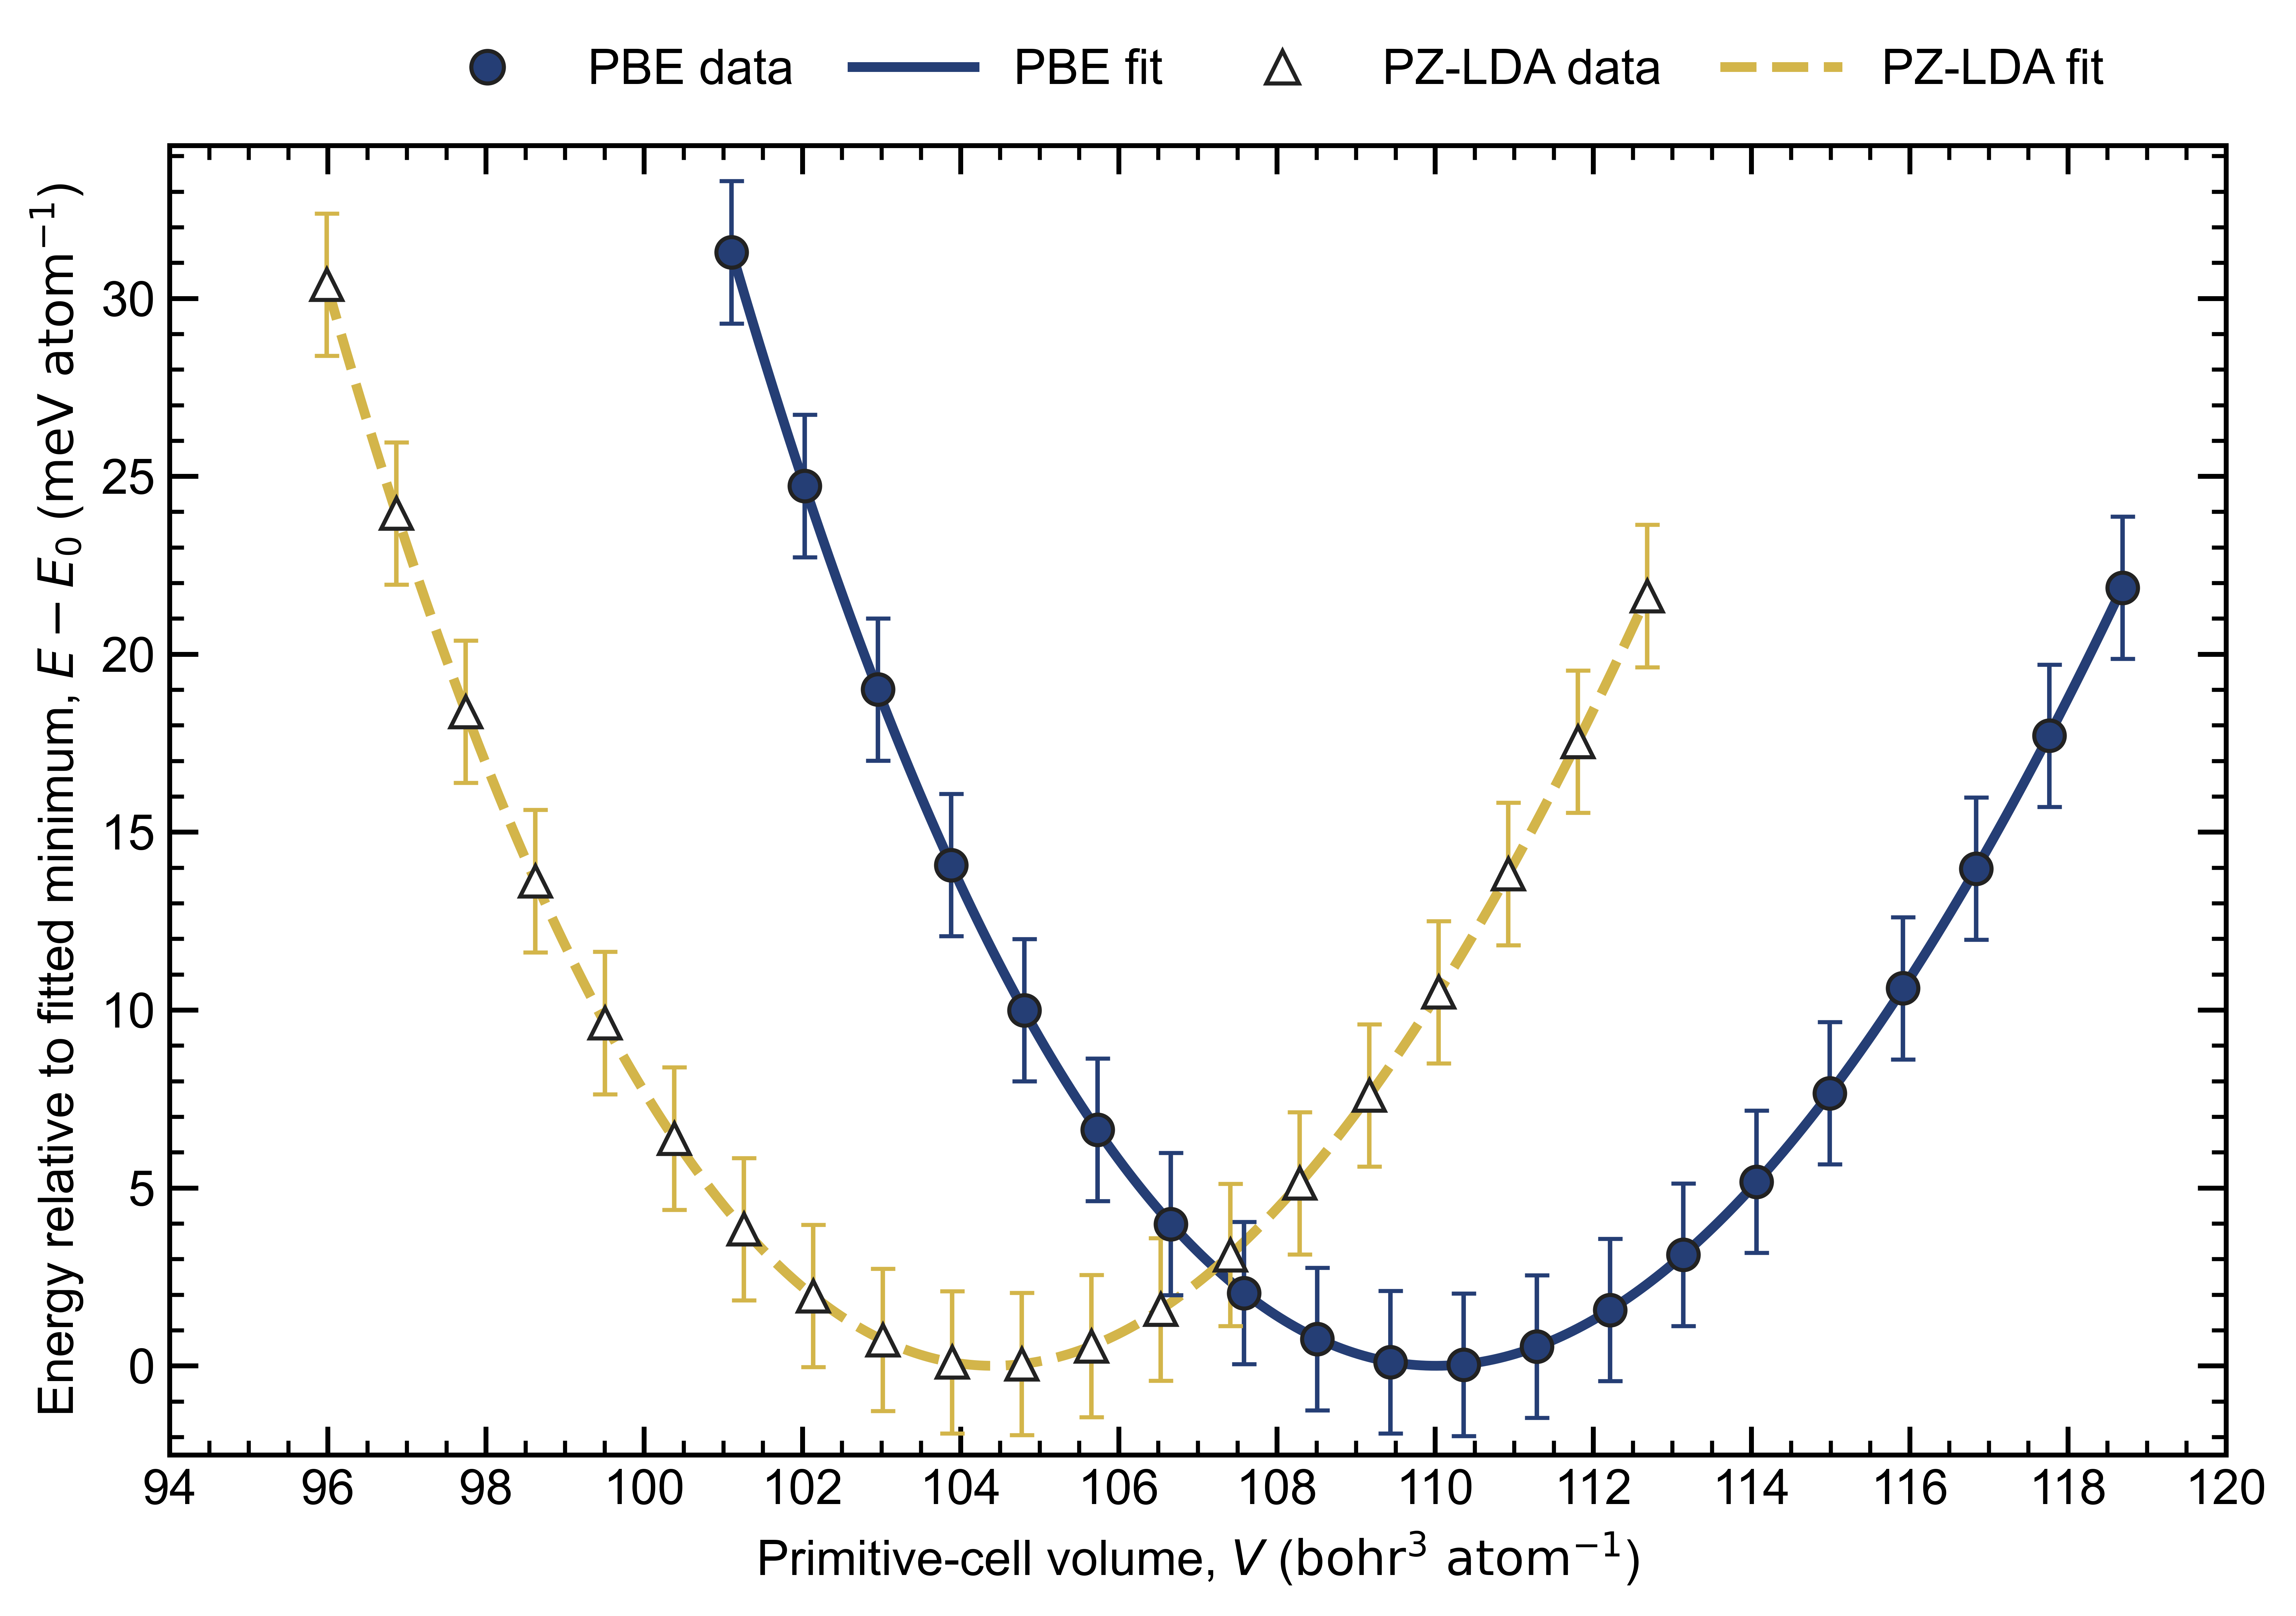

PBE:    a0 = 4.02496 Å, B0 = 79.93 GPa, B0′ = 4.788
PZ-LDA: a0 = 3.95550 Å, B0 = 82.47 GPa, B0′ = 4.687

Caption:
PBE and PZ-LDA fcc-Al energy–volume data and third-order Birch–Murnaghan fits. Each dataset is shifted by its fitted minimum energy, placing both minima at zero for direct curvature comparison; error bars show the 2 meV atom$^{-1}$ convergence tolerance.


In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from scipy.optimize import curve_fit

RY_TO_MEV = 13605.693122994
RY_BOHR3_TO_GPA = 14710.507848
BOHR_TO_ANGSTROM = 0.529177210903

# Preserve the report palette and figure style.
NAVY = "#253E75"
GOLD = "#D3B54A"
EDGE = "#222222"

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.fontset": "dejavusans",
    "font.size": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.linewidth": 1.2,
    "savefig.dpi": 900,
})

def birch_murnaghan(V, E0, V0, B0_GPa, B0_prime):
    """Third-order Birch–Murnaghan E(V); V in bohr^3, E in Ry."""
    x = (V0 / V)**(2.0 / 3.0)
    B0_Ry_bohr3 = B0_GPa / RY_BOHR3_TO_GPA
    return E0 + (9.0 * V0 * B0_Ry_bohr3 / 16.0) * (
        (x - 1.0)**3 * B0_prime
        + (x - 1.0)**2 * (6.0 - 4.0 * x)
    )

def load_and_fit(csv_file):
    data = pd.read_csv(csv_file)
    data = data[data["status"].isin(["success", "cached"])].copy()
    data = data.sort_values("volume_bohr3")

    V = data["volume_bohr3"].to_numpy(float)
    E = data["energy_ry"].to_numpy(float)

    initial_guess = [E.min(), V[E.argmin()], 80.0, 4.0]
    parameters, covariance = curve_fit(
        birch_murnaghan, V, E, p0=initial_guess, maxfev=100_000
    )

    E0, V0, B0_GPa, B0_prime = parameters
    uncertainties = np.sqrt(np.diag(covariance))
    alat_ang = (4.0 * V0)**(1.0 / 3.0) * BOHR_TO_ANGSTROM

    return {
        "V": V,
        "E": E,
        "E0": E0,
        "V0": V0,
        "B0_GPa": B0_GPa,
        "B0_prime": B0_prime,
        "uncertainties": uncertainties,
        "alat_ang": alat_ang,
    }

pbe = load_and_fit(Path("eos-runs/results.csv"))
lda = load_and_fit(Path("lda-eos-runs/results.csv"))

fig, ax = plt.subplots(figsize=(8, 6), dpi=900)

for result, color, marker, line_style, label in [
    (pbe, NAVY, "o", "-", "PBE"),
    (lda, GOLD, "^", "--", "PZ-LDA"),
]:
    V = result["V"]
    energy_shifted = (result["E"] - result["E0"]) * RY_TO_MEV
    V_fit = np.linspace(V.min(), V.max(), 800)
    fit_shifted = (
        birch_murnaghan(
            V_fit,
            result["E0"],
            result["V0"],
            result["B0_GPa"],
            result["B0_prime"],
        )
        - result["E0"]
    ) * RY_TO_MEV

    ax.errorbar(
        V,
        energy_shifted,
        yerr=2.0,  # stated convergence tolerance
        fmt=marker,
        linestyle="none",
        markersize=7.5,
        markerfacecolor=color if label == "PBE" else "white",
        markeredgecolor=EDGE,
        markeredgewidth=1.0,
        ecolor=color,
        elinewidth=1.1,
        capsize=3,
        zorder=3,
    )
    ax.plot(V_fit, fit_shifted, color=color, linewidth=2.4,
            linestyle=line_style, zorder=2)

x_min = 2.0 * np.floor(min(pbe["V"].min(), lda["V"].min()) / 2.0)
x_max = 2.0 * np.ceil(max(pbe["V"].max(), lda["V"].max()) / 2.0)
y_max = max(
    ((pbe["E"] - pbe["E0"]) * RY_TO_MEV).max(),
    ((lda["E"] - lda["E0"]) * RY_TO_MEV).max(),
) + 3.0

ax.set_xlim(x_min, x_max)
ax.set_ylim(-2.5, y_max)
ax.set_xlabel(r"Primitive-cell volume, $V$ ($\mathrm{bohr^3\ atom^{-1}}$)")
ax.set_ylabel(r"Energy relative to fitted minimum, $E-E_0$ ($\mathrm{meV\ atom^{-1}}$)")

ax.xaxis.set_major_locator(MultipleLocator(2))
ax.xaxis.set_minor_locator(AutoMinorLocator(4))
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax.tick_params(which="major", direction="in", length=7, width=1.2, top=True, right=True)
ax.tick_params(which="minor", direction="in", length=3.5, width=1.0, top=True, right=True)

legend_handles = [
    Line2D([], [], marker="o", linestyle="none", markersize=8,
           markerfacecolor=NAVY, markeredgecolor=EDGE, label="PBE data"),
    Line2D([], [], color=NAVY, linewidth=2.4, label="PBE fit"),
    Line2D([], [], marker="^", linestyle="none", markersize=8,
           markerfacecolor="white", markeredgecolor=EDGE, label="PZ-LDA data"),
    Line2D([], [], color=GOLD, linewidth=2.4, linestyle="--", label="PZ-LDA fit"),
]
fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.55, 0.93),
    handlelength=2.5,
    columnspacing=1.2,
)

fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.88))
fig.savefig("A3_PBE_LDA_EOS_comparison.png", dpi=900, bbox_inches="tight")
plt.show()

print(
    f"PBE:    a0 = {pbe['alat_ang']:.5f} Å, "
    f"B0 = {pbe['B0_GPa']:.2f} GPa, B0′ = {pbe['B0_prime']:.3f}"
)
print(
    f"PZ-LDA: a0 = {lda['alat_ang']:.5f} Å, "
    f"B0 = {lda['B0_GPa']:.2f} GPa, B0′ = {lda['B0_prime']:.3f}"
)

caption = (
    "PBE and PZ-LDA fcc-Al energy–volume data and third-order "
    "Birch–Murnaghan fits. Each dataset is shifted by its fitted minimum "
    "energy, placing both minima at zero for direct curvature comparison; "
    "error bars show the 2 meV atom$^{-1}$ convergence tolerance."
)
print("\nCaption:\n" + caption)

In [ ]:
#!/usr/bin/env python3
"""Generate the A5 fcc-Al SCF and band-path inputs; never launches QE.

The path is the course-specified fcc path
Gamma-X-W-K-Gamma-L-U-W-L-K.  Points are allocated by Cartesian reciprocal
length, so consecutive points have approximately uniform physical spacing.
"""

from __future__ import annotations

import csv
import math
from pathlib import Path


PROJECT = Path(__file__).resolve().parents[1]
PSEUDO = PROJECT / "Al.pbe-n-van.UPF"
OUTDIR = PROJECT / "qe-out" / "a5-bands"
PREFIX = "aluminum_a5_bands"

# PBE Birch-Murnaghan minimum from A3: a0 = 4.02496285 Angstrom.
BOHR_TO_ANGSTROM = 0.529177210903
ALAT_BOHR = 4.02496285 / BOHR_TO_ANGSTROM

# Converged PBE settings selected in A2.
ECUTWFC_RY = 35.0
ECUTRHO_RY = 280.0  # 8 * ecutwfc for the ultrasoft Vanderbilt UPF.
KMESH = 16
DEGAUSS_RY = 0.01
NBND = 8
NPOINTS = 240

# Conventional Cartesian coordinates in units of 2*pi/a.  These are converted
# to QE's primitive reciprocal "crystal" coordinates below for ibrav = 2.
PATH = (
    ("Γ", (0.00, 0.00, 0.00)),
    ("X", (0.00, 1.00, 0.00)),
    ("W", (0.50, 1.00, 0.00)),
    ("K", (0.75, 0.75, 0.00)),
    ("Γ", (0.00, 0.00, 0.00)),
    ("L", (0.50, 0.50, 0.50)),
    ("U", (0.25, 1.00, 0.25)),
    ("W", (0.50, 1.00, 0.00)),
    ("L", (0.50, 0.50, 0.50)),
    ("K", (0.75, 0.75, 0.00)),
)


def sub(a: tuple[float, float, float], b: tuple[float, float, float]) -> tuple[float, float, float]:
    return tuple(x - y for x, y in zip(a, b))  # type: ignore[return-value]


def add(a: tuple[float, float, float], b: tuple[float, float, float]) -> tuple[float, float, float]:
    return tuple(x + y for x, y in zip(a, b))  # type: ignore[return-value]


def scale(a: tuple[float, float, float], factor: float) -> tuple[float, float, float]:
    return tuple(factor * x for x in a)  # type: ignore[return-value]


def norm(a: tuple[float, float, float]) -> float:
    return math.sqrt(sum(x * x for x in a))


def fcc_cartesian_to_crystal(k: tuple[float, float, float]) -> tuple[float, float, float]:
    """Convert 2*pi/a Cartesian fcc coordinates to QE ibrav=2 coefficients.

    QE's reciprocal primitive vectors are (-1,-1,1), (1,1,1), and
    (-1,1,-1), each in units of 2*pi/a.
    """

    x, y, z = k
    return ((z - x) / 2.0, (y + z) / 2.0, (y - x) / 2.0)


def allocate_intervals(lengths: list[float], npoints: int) -> list[int]:
    """Allocate exactly npoints - 1 intervals in proportion to length."""

    if npoints < len(lengths) + 1:
        raise ValueError(f"Need at least {len(lengths) + 1} points, got {npoints}.")

    total_intervals = npoints - 1
    total_length = sum(lengths)
    raw = [total_intervals * length / total_length for length in lengths]
    intervals = [max(1, math.floor(value)) for value in raw]
    missing = total_intervals - sum(intervals)
    order = sorted(range(len(raw)), key=lambda i: raw[i] - math.floor(raw[i]), reverse=True)
    for i in order[:missing]:
        intervals[i] += 1
    return intervals


def make_kpath() -> tuple[list[tuple[float, float, float]], list[int], list[int]]:
    cartesian = [coordinate for _, coordinate in PATH]
    lengths = [norm(sub(stop, start)) for start, stop in zip(cartesian[:-1], cartesian[1:])]
    intervals = allocate_intervals(lengths, NPOINTS)

    points = [cartesian[0]]
    high_symmetry_indices = [0]
    for start, stop, nintervals in zip(cartesian[:-1], cartesian[1:], intervals):
        direction = sub(stop, start)
        for step in range(1, nintervals + 1):
            points.append(add(start, scale(direction, step / nintervals)))
        high_symmetry_indices.append(len(points) - 1)

    assert len(points) == NPOINTS
    return points, intervals, high_symmetry_indices


def write_inputs() -> None:
    if not PSEUDO.is_file():
        raise FileNotFoundError(f"Required pseudopotential not found: {PSEUDO}")

    kpoints_cart, intervals, special_indices = make_kpath()
    kpoints_crystal = [fcc_cartesian_to_crystal(point) for point in kpoints_cart]
    outdir = OUTDIR.resolve().as_posix() + "/"
    pseudo_dir = PSEUDO.parent.resolve().as_posix() + "/"

    scf_input = f"""&CONTROL
  calculation = 'scf',
  restart_mode = 'from_scratch',
  prefix = '{PREFIX}',
  pseudo_dir = '{pseudo_dir}',
  outdir = '{outdir}'
/
&SYSTEM
  ibrav = 2,
  celldm(1) = {ALAT_BOHR:.10f},
  nat = 1,
  ntyp = 1,
  ecutwfc = {ECUTWFC_RY:.1f},
  ecutrho = {ECUTRHO_RY:.1f},
  occupations = 'smearing',
  smearing = 'methfessel-paxton',
  degauss = {DEGAUSS_RY:.2f}
/
&ELECTRONS
  diagonalization = 'david',
  conv_thr = 1.0d-10,
  mixing_mode = 'plain'
/
ATOMIC_SPECIES
  Al  26.982  {PSEUDO.name}
ATOMIC_POSITIONS alat
  Al  0.00  0.00  0.00
K_POINTS automatic
  {KMESH} {KMESH} {KMESH}  0 0 0
"""

    kpoint_lines = "\n".join(f"  {kx: .10f}  {ky: .10f}  {kz: .10f}  1.0" for kx, ky, kz in kpoints_crystal)
    bands_input = f"""&CONTROL
  calculation = 'bands',
  verbosity = 'high',
  prefix = '{PREFIX}',
  pseudo_dir = '{pseudo_dir}',
  outdir = '{outdir}'
/
&SYSTEM
  ibrav = 2,
  celldm(1) = {ALAT_BOHR:.10f},
  nat = 1,
  ntyp = 1,
  ecutwfc = {ECUTWFC_RY:.1f},
  ecutrho = {ECUTRHO_RY:.1f},
  occupations = 'smearing',
  smearing = 'methfessel-paxton',
  degauss = {DEGAUSS_RY:.2f},
  nbnd = {NBND},
  nosym = .true.
/
&ELECTRONS
  diagonalization = 'david',
  diago_full_acc = .true.
/
ATOMIC_SPECIES
  Al  26.982  {PSEUDO.name}
ATOMIC_POSITIONS alat
  Al  0.00  0.00  0.00
K_POINTS crystal
{len(kpoints_crystal)}
{kpoint_lines}
"""

    (PROJECT / "Al.band.scf.inp").write_text(scf_input)
    (PROJECT / "Al.band.inp").write_text(bands_input)

    distance = 0.0
    rows = []
    special_lookup = {index: PATH[position][0] for position, index in enumerate(special_indices)}
    for index, (cartesian, crystal) in enumerate(zip(kpoints_cart, kpoints_crystal)):
        if index:
            distance += norm(sub(cartesian, kpoints_cart[index - 1]))
        rows.append(
            {
                "index": index,
                "segment": next(i for i, endpoint in enumerate(special_indices[1:]) if index <= endpoint),
                "label": special_lookup.get(index, ""),
                "distance_2pi_over_a": f"{distance:.10f}",
                "kx_cart_2pi_over_a": f"{cartesian[0]:.10f}",
                "ky_cart_2pi_over_a": f"{cartesian[1]:.10f}",
                "kz_cart_2pi_over_a": f"{cartesian[2]:.10f}",
                "k1_crystal": f"{crystal[0]:.10f}",
                "k2_crystal": f"{crystal[1]:.10f}",
                "k3_crystal": f"{crystal[2]:.10f}",
            }
        )
    csv_path = PROJECT / "a5-bands-kpath.csv"
    with csv_path.open("w", newline="") as stream:
        writer = csv.DictWriter(stream, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)

    segment_report = ", ".join(
        f"{PATH[i][0]}–{PATH[i + 1][0]}: {count}" for i, count in enumerate(intervals)
    )
    spacings = [
        norm(sub(kpoints_cart[i], kpoints_cart[i - 1])) for i in range(1, len(kpoints_cart))
    ]
    print(f"Wrote {PROJECT / 'Al.band.scf.inp'}")
    print(f"Wrote {PROJECT / 'Al.band.inp'}")
    print(f"Wrote {csv_path}")
    print(f"Generated {len(kpoints_cart)} fcc-path points ({segment_report}).")
    print(
        "Reciprocal spacing (2π/a): "
        f"min = {min(spacings):.6f}, max = {max(spacings):.6f}; "
        f"a = {ALAT_BOHR:.8f} bohr."
    )


if __name__ == "__main__":
    write_inputs()


In [ ]:
#!/usr/bin/env python3
"""Plot the A5 fcc-Al bands relative to the Fermi level from the A5 SCF run."""

from __future__ import annotations

import argparse
import csv
import re
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import AutoMinorLocator


PROJECT = Path(__file__).resolve().parents[1]
BOHR_TO_ANGSTROM = 0.529177210903
A0_ANGSTROM = 4.02496285
ALAT_BOHR = A0_ANGSTROM / BOHR_TO_ANGSTROM

# Persistent report palette: navy = PBE, gold = PZ-LDA, gray = reference.
PBE_NAVY = "#253E75"
REFERENCE_GRAY = "#5A5A5A"

FERMI_PATTERN = re.compile(
    r"the\s+Fermi\s+energy\s+is\s+([-+]?\d*\.?\d+(?:[EeDd][-+]?\d+)?)\s+ev",
    re.IGNORECASE,
)
NBND_PATTERN = re.compile(r"number\s+of\s+Kohn-Sham\s+states\s*=\s*(\d+)", re.IGNORECASE)
KPOINT_PATTERN = re.compile(
    r"^\s*k\s*=\s*"
    r"([-+]?\d*\.?\d+(?:[EeDd][-+]?\d+)?)\s+"
    r"([-+]?\d*\.?\d+(?:[EeDd][-+]?\d+)?)\s*"
    r"([-+]?\d*\.?\d+(?:[EeDd][-+]?\d+)?)"
    r".*bands\s*\(ev\):",
    re.IGNORECASE,
)


def qe_float(token: str) -> float:
    return float(token.replace("D", "E").replace("d", "e"))


def require_finished(path: Path) -> str:
    if not path.is_file():
        raise FileNotFoundError(f"Output file not found: {path}")
    text = path.read_text(errors="replace")
    if "JOB DONE." not in text:
        raise RuntimeError(f"QE did not finish cleanly: {path}")
    return text


def read_fermi_energy(scf_output: Path) -> float:
    matches = FERMI_PATTERN.findall(require_finished(scf_output))
    if not matches:
        raise ValueError(f"Could not find 'the Fermi energy is ... ev' in {scf_output}")
    return qe_float(matches[-1])


def read_band_eigenvalues(bands_output: Path) -> tuple[np.ndarray, np.ndarray]:
    text = require_finished(bands_output)
    state_matches = NBND_PATTERN.findall(text)
    if not state_matches:
        raise ValueError(f"Could not determine nbnd from {bands_output}")
    nbnd = int(state_matches[-1])

    kpoints: list[tuple[float, float, float]] = []
    rows: list[list[float]] = []
    current_k: tuple[float, float, float] | None = None
    current_energies: list[float] = []

    for line in text.splitlines():
        match = KPOINT_PATTERN.match(line)
        if match:
            if current_k is not None:
                raise ValueError("Encountered a new k-point before collecting all its eigenvalues.")
            current_k = tuple(qe_float(value) for value in match.groups())
            current_energies = []
            continue

        if current_k is None:
            continue

        tokens = line.split()
        if not tokens:
            continue
        try:
            current_energies.extend(qe_float(token) for token in tokens)
        except ValueError:
            continue

        if len(current_energies) == nbnd:
            kpoints.append(current_k)
            rows.append(current_energies)
            current_k = None
        elif len(current_energies) > nbnd:
            raise ValueError("Parsed more eigenvalues than the reported number of bands.")

    if current_k is not None:
        raise ValueError("The last k-point did not contain a complete set of eigenvalues.")
    if not rows:
        raise ValueError(f"No band eigenvalues were parsed from {bands_output}")
    return np.asarray(kpoints, dtype=float), np.asarray(rows, dtype=float)


def read_kpath(kpath_csv: Path) -> tuple[np.ndarray, np.ndarray, list[str], np.ndarray]:
    if not kpath_csv.is_file():
        raise FileNotFoundError(
            f"Path table not found: {kpath_csv}. Run 'python3 scripts/al_bands.py' first."
        )
    rows = list(csv.DictReader(kpath_csv.open()))
    if not rows:
        raise ValueError(f"No k-path rows found in {kpath_csv}")

    distance_2pi_over_a = np.asarray([float(row["distance_2pi_over_a"]) for row in rows])
    cartesian_kpoints = np.asarray(
        [
            [
                float(row["kx_cart_2pi_over_a"]),
                float(row["ky_cart_2pi_over_a"]),
                float(row["kz_cart_2pi_over_a"]),
            ]
            for row in rows
        ]
    )
    labels = [row["label"] for row in rows]
    special_indices = np.asarray([index for index, label in enumerate(labels) if label])
    return distance_2pi_over_a, cartesian_kpoints, labels, special_indices


def make_figure(
    distance_bohr_inv: np.ndarray,
    labels: list[str],
    special_indices: np.ndarray,
    energies_ev: np.ndarray,
    fermi_ev: float,
    output: Path,
) -> None:
    mpl.rcParams.update(
        {
            "font.family": "sans-serif",
            "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
            "font.size": 14,
            "axes.labelsize": 16,
            "xtick.labelsize": 14,
            "ytick.labelsize": 14,
            "legend.fontsize": 13,
            "axes.linewidth": 1.3,
            "mathtext.fontset": "dejavusans",
        }
    )

    fig, axis = plt.subplots(figsize=(7.6, 4.6), dpi=900)
    for band in energies_ev.T:
        axis.plot(distance_bohr_inv, band - fermi_ev, color=PBE_NAVY, linewidth=1.20, zorder=2)

    axis.plot([], [], color=PBE_NAVY, linewidth=1.55, label="PBE Kohn–Sham bands")
    axis.axhline(0.0, color=REFERENCE_GRAY, linestyle="--", linewidth=1.10, label=r"Fermi level, $E-E_F=0$")

    high_symmetry_distance = distance_bohr_inv[special_indices]
    for location in high_symmetry_distance:
        axis.axvline(location, color=REFERENCE_GRAY, linewidth=0.70, alpha=0.55, zorder=0)

    axis.set_xticks(high_symmetry_distance, [labels[index] for index in special_indices])
    axis.set_xlabel(r"Cumulative reciprocal-space distance, $s$ (bohr$^{-1}$)")
    axis.set_ylabel(r"Energy relative to Fermi energy, $E-E_F$ (eV)")
    axis.xaxis.set_minor_locator(AutoMinorLocator(4))
    axis.yaxis.set_minor_locator(AutoMinorLocator(4))
    axis.tick_params(which="major", direction="in", top=True, right=True, length=7, width=1.25)
    axis.tick_params(which="minor", direction="in", top=True, right=True, length=3.5, width=0.90)
    axis.margins(x=0.015, y=0.06)
    axis.legend(
        loc="lower center",
        bbox_to_anchor=(0.5, 1.01),
        ncol=2,
        frameon=False,
        handlelength=2.8,
        columnspacing=1.7,
    )
    fig.tight_layout(pad=0.35)
    fig.savefig(output, dpi=900, bbox_inches="tight", pad_inches=0.04)


def main() -> None:
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--scf-output", type=Path, default=PROJECT / "qe-results" / "Al.band.scf.out")
    parser.add_argument("--bands-output", type=Path, default=PROJECT / "qe-results" / "Al.band.out")
    parser.add_argument("--kpath", type=Path, default=PROJECT / "a5-bands-kpath.csv")
    parser.add_argument("--output", type=Path, default=PROJECT / "A5_band_structure.png")
    arguments = parser.parse_args()

    fermi_ev = read_fermi_energy(arguments.scf_output)
    qe_kpoints, energies_ev = read_band_eigenvalues(arguments.bands_output)
    distance_2pi_over_a, expected_kpoints, labels, special_indices = read_kpath(arguments.kpath)

    if len(qe_kpoints) != len(expected_kpoints):
        raise ValueError(
            f"QE returned {len(qe_kpoints)} k-points but the generated path has "
            f"{len(expected_kpoints)}. Confirm that Al.band.inp was regenerated before running."
        )
    coordinate_error = np.linalg.norm(qe_kpoints - expected_kpoints, axis=1).max()
    if coordinate_error > 2.0e-4:
        raise ValueError(
            f"QE k-point order does not match the generated fcc path "
            f"(maximum coordinate error {coordinate_error:.3e} in 2π/a)."
        )

    distance_bohr_inv = distance_2pi_over_a * 2.0 * np.pi / ALAT_BOHR
    make_figure(distance_bohr_inv, labels, special_indices, energies_ev, fermi_ev, arguments.output)
    print(f"Fermi energy from SCF: {fermi_ev:.6f} eV")
    print(f"Parsed {len(qe_kpoints)} k-points and {energies_ev.shape[1]} bands.")
    print(f"Maximum k-point mismatch: {coordinate_error:.3e} in 2π/a")
    print(f"Wrote {arguments.output.resolve()}")


if __name__ == "__main__":
    main()


In [ ]:
#!/usr/bin/env python3
"""Plot the A5 total DOS from QE dos.x relative to the NSCF Fermi level."""

from __future__ import annotations

import argparse
import re
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import AutoMinorLocator


PROJECT = Path(__file__).resolve().parents[1]
PBE_NAVY = "#253E75"
REFERENCE_GRAY = "#5A5A5A"
FERMI_PATTERN = re.compile(
    r"the\s+Fermi\s+energy\s+is\s+([-+]?\d*\.?\d+(?:[EeDd][-+]?\d+)?)\s+ev",
    re.IGNORECASE,
)


def require_finished(path: Path) -> str:
    if not path.is_file():
        raise FileNotFoundError(f"Output file not found: {path}")
    text = path.read_text(errors="replace")
    if "JOB DONE." not in text:
        raise RuntimeError(f"QE did not finish cleanly: {path}")
    return text


def read_fermi_energy(nscf_output: Path) -> float:
    matches = FERMI_PATTERN.findall(require_finished(nscf_output))
    if not matches:
        raise ValueError(f"Could not find the NSCF Fermi energy in {nscf_output}")
    return float(matches[-1].replace("D", "E").replace("d", "e"))


def read_dos(dos_file: Path) -> tuple[np.ndarray, np.ndarray]:
    if not dos_file.is_file():
        raise FileNotFoundError(f"DOS table not found: {dos_file}")
    try:
        data = np.loadtxt(dos_file, comments="#")
    except ValueError as error:
        raise ValueError(f"Could not parse numeric DOS columns in {dos_file}") from error
    if data.ndim != 2 or data.shape[1] < 2:
        raise ValueError(f"Expected energy and DOS columns in {dos_file}")
    if np.any(data[:, 1] < -1.0e-10):
        raise ValueError("The total DOS contains unphysical negative values.")
    return data[:, 0], data[:, 1]


def make_figure(energy_ev: np.ndarray, dos: np.ndarray, fermi_ev: float, output: Path) -> None:
    mpl.rcParams.update(
        {
            "font.family": "sans-serif",
            "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
            "font.size": 14,
            "axes.labelsize": 16,
            "xtick.labelsize": 14,
            "ytick.labelsize": 14,
            "legend.fontsize": 13,
            "axes.linewidth": 1.3,
            "mathtext.fontset": "dejavusans",
        }
    )

    energy_relative_ev = energy_ev - fermi_ev
    fig, axis = plt.subplots(figsize=(7.6, 4.6), dpi=900)
    axis.plot(energy_relative_ev, dos, color=PBE_NAVY, linewidth=1.65, label="PBE total DOS")
    axis.axvline(
        0.0,
        color=REFERENCE_GRAY,
        linestyle="--",
        linewidth=1.10,
        label=r"Fermi level, $E-E_F=0$",
    )
    axis.set_xlabel(r"Energy relative to Fermi level, $E-E_F$ (eV)")
    axis.set_ylabel(r"Density of states, $D(E)$ (states eV$^{-1}$ atom$^{-1}$)")
    axis.set_xlim(energy_relative_ev.min(), energy_relative_ev.max())
    axis.set_ylim(bottom=0.0)
    axis.xaxis.set_minor_locator(AutoMinorLocator(4))
    axis.yaxis.set_minor_locator(AutoMinorLocator(4))
    axis.tick_params(which="major", direction="in", top=True, right=True, length=7, width=1.25)
    axis.tick_params(which="minor", direction="in", top=True, right=True, length=3.5, width=0.90)
    axis.legend(
        loc="lower center",
        bbox_to_anchor=(0.5, 1.01),
        ncol=2,
        frameon=False,
        handlelength=2.8,
        columnspacing=1.7,
    )
    fig.tight_layout(pad=0.35)
    fig.savefig(output, dpi=900, bbox_inches="tight", pad_inches=0.04)


def main() -> None:
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument(
        "--nscf-output", type=Path, default=PROJECT / "qe-results" / "Al.dos.nscf.out"
    )
    parser.add_argument("--dos-output", type=Path, default=PROJECT / "qe-results" / "Al.dos.out")
    parser.add_argument("--dos-file", type=Path, default=PROJECT / "qe-results" / "Al.dos.dat")
    parser.add_argument("--output", type=Path, default=PROJECT / "A5_density_of_states.png")
    arguments = parser.parse_args()

    require_finished(arguments.dos_output)
    fermi_ev = read_fermi_energy(arguments.nscf_output)
    energy_ev, dos = read_dos(arguments.dos_file)
    make_figure(energy_ev, dos, fermi_ev, arguments.output)
    print(f"NSCF Fermi energy: {fermi_ev:.6f} eV")
    print(f"Read {len(energy_ev)} DOS points from {arguments.dos_file.resolve()}")
    print(f"Wrote {arguments.output.resolve()}")


if __name__ == "__main__":
    main()
